### **НАВИГАЦИЯ:**
[<span> 1. Познакомьтесь с данными.](#1)<br>
[<span> 2. Осуществите предобработку данных.](#2)<br>
  * [*<span>2.1 Приведите заголовки к удобному виду.*](#3)<br>
  * [*<span>2.2 Проверьте типы данных.</span>*](#4)<br>
  * [*<span>2.3 Обработайте пропуски.</span>*](#5)<br>
  * [*<span>2.4 Проверьте наличие дубликатов.</span>*](#6)<br>
  * [*<span>2.5 Исключите нулевые значения в выручке для дальнейшего исследования.</span>*](#7)<br> 

  [<span> 3. Исследовательский анализ данных:</span>](#8)<br>
  * [*<span> 3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE. Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.</span>*](#9)<br>
  * [*<span> 3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных. </span>*](#10)<br>
  * [*<span> 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию. </span>*](#11)<br>
  * [*<span> 3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы. </span>*](#12)<br>
  * [*<span> 3 .5  Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета: https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat </span>*](#13)<br>
  * [*<span> 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций. </span>*](#14)<br>

In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t, norm
from scipy import stats as st

## <a class="anchor" id="1"></a> 1. Познакомьтесь с данными.

In [2]:
#Загружаем данные
df=pd.read_csv('air_data.csv',sep=';')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ISSUE_DATE         50000 non-null  object
 1   FLIGHT_DATE_LOC    50000 non-null  object
 2   PAX_TYPE           50000 non-null  object
 3   REVENUE_AMOUNT     50000 non-null  int64 
 4   ORIG_CITY_CODE     49998 non-null  object
 5   DEST_CITY_CODE     49999 non-null  object
 6   ROUTE_FLIGHT_TYPE  50000 non-null  object
 7   FFP_FLAG           19398 non-null  object
 8   SALE_TYPE          50000 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.4+ MB


In [4]:
df.shape

(50000, 9)

In [5]:
df.describe()

,REVENUE_AMOUNT
count,50000.000000
mean,433.718600
std,217.933916
min,0.000000
25%,280.000000
50%,400.000000
75%,550.000000
max,5200.000000


In [6]:
df.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


#### Исходный датасет содержит 50 000 строк и 9 столбцов с данными о продаже билетов авиакомпании. Средняя выручка составила около 433.71 ден.ед, а максимальная - 5000.

## <a class="anchor" id="2"></a>2. Осуществите предобработку данных
### <a class="anchor" id="3"></a> 2.1. Приведите заголовки к удобному виду

In [7]:
#Приведем столбцы к нижнему регистру
df.columns=df.columns.str.lower()
df

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE
...,...,...,...,...,...,...,...,...,...
49995,2022-06-11 00:00:00,2022-06-22 00:00:00,CHD,480,MOW,OMS,ВВЛ,NaN,ONLINE
49996,2022-06-06 00:00:00,2022-06-20 00:00:00,AD,270,LED,MOW,ВВЛ,NaN,OFFLINE
49997,2022-06-26 00:00:00,2022-06-29 00:00:00,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE
49998,2022-06-26 00:00:00,2022-06-28 00:00:00,AD,270,KZN,MOW,ВВЛ,NaN,OFFLINE


### <a class="anchor" id="4"></a> 2.2. Проверьте типы данных

In [8]:
df.dtypes

issue_date           object
flight_date_loc      object
pax_type             object
revenue_amount        int64
orig_city_code       object
dest_city_code       object
route_flight_type    object
ffp_flag             object
sale_type            object
dtype: object

#### Столбцы issue_date и flight_date_loc содержат информацию о датах продажи билетов и датах вылета рейсов. Их необходимо привести к типу datetime64[ns]

In [9]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['flight_date_loc'] = pd.to_datetime(df['flight_date_loc'])

In [10]:
df.head()

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


### <a class="anchor" id="5"></a> 2.3 Обработайте пропуски.

In [11]:
df.isna().sum()

issue_date               0
flight_date_loc          0
pax_type                 0
revenue_amount           0
orig_city_code           2
dest_city_code           1
route_flight_type        0
ffp_flag             30602
sale_type                0
dtype: int64

In [12]:
#Сперва обработаем 2 пропуска в столбце orig_city_code
df['orig_city_code'].describe()

count     49998
unique      146
top         MOW
freq      16122
Name: orig_city_code, dtype: object

In [13]:
df[df['orig_city_code'].isna()]

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
2020,2022-02-17,2022-03-22,AD,440,NaN,KHV,МВЛ,NaN,ONLINE
8100,2022-05-02,2022-05-11,AD,440,NaN,KHV,МВЛ,NaN,OFFLINE


#### Оба пропущенных значения имеют точку назначения - код аэропорта Хабаровска, причем рейс международный, так как route_flight_type = МВЛ. Проверим все рейсы, подходящие под данные условия

In [14]:
df.query('route_flight_type == "МВЛ" and dest_city_code == "KHV"')

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
120,2021-12-06,2022-01-15,AD,1030,BKK,KHV,МВЛ,FFP,OFFLINE
2020,2022-02-17,2022-03-22,AD,440,NaN,KHV,МВЛ,NaN,ONLINE
8100,2022-05-02,2022-05-11,AD,440,NaN,KHV,МВЛ,NaN,OFFLINE
28684,2021-11-16,2022-01-22,CHD,970,BKK,KHV,МВЛ,NaN,OFFLINE
28734,2021-11-15,2022-01-22,CHD,850,BKK,KHV,МВЛ,NaN,OFFLINE
30756,2021-11-11,2022-01-29,AD,850,BKK,KHV,МВЛ,NaN,OFFLINE


In [15]:
#Так как международные рейсы в Хабаровск летали только из Бангкока, а рейсы из Хабаровска также летали только в Бангкок, то заполним пропущенные значения на 'BKK'
df['orig_city_code']= df['orig_city_code'].fillna('BKK')

In [16]:
#Проверим пропущенное значение в столбце dest_city_code
df[df['dest_city_code'].isna()]

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
47582,2022-05-13,2022-07-28,AD,440,KHV,NaN,МВЛ,NaN,OFFLINE


#### Рейс был совершен из Хабаровска, он также международный, скорее всего полетит в Бангкок, проверим еще раз:

In [17]:
df.query('route_flight_type == "МВЛ" and orig_city_code == "KHV"')

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
24361,2021-12-30,2021-12-31,AD,1080,KHV,BKK,МВЛ,NaN,OFFLINE
36137,2022-01-18,2022-01-21,AD,810,KHV,BKK,МВЛ,FFP,ONLINE
45968,2021-12-10,2021-12-31,AD,970,KHV,BKK,МВЛ,NaN,ONLINE
47582,2022-05-13,2022-07-28,AD,440,KHV,NaN,МВЛ,NaN,OFFLINE


In [18]:
#Заменим пропущенное значение на код аэропорта Бангкока
df['dest_city_code']= df['dest_city_code'].fillna('BKK')

In [19]:
#заполним пропуски в ffp_flag, для этого посмотрим уникальные значения
df['ffp_flag'].unique()

array([nan, 'FFP'], dtype=object)

##### Поскольку переменная бинарная, заполним пропущенное значение на 'NO_FFP'

In [20]:
df['ffp_flag'] = df['ffp_flag'].fillna('NO_FFP')

### <a class="anchor" id="6"></a>2.4. Проверьте наличие дубликатов

In [21]:
df.duplicated().sum()

np.int64(169)

In [22]:
#Удалим дубликаты
df = df.drop_duplicates().reset_index()

### <a class="anchor" id="7"></a> 2.5. Исключите нулевые значения выручки для дальнейшего исследования

In [23]:
df.query('revenue_amount == 0')

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
13,13,2021-12-05,2022-01-16,INF,0,PEZ,MOW,ВВЛ,NO_FFP,OFFLINE
32,32,2021-12-08,2022-01-11,INF,0,UFA,MOW,ВВЛ,NO_FFP,ONLINE
106,106,2021-12-05,2022-01-08,INF,0,MOW,UFA,ВВЛ,NO_FFP,ONLINE
228,228,2021-12-04,2022-01-07,INF,0,MOW,AER,ВВЛ,NO_FFP,ONLINE
288,288,2021-10-26,2021-11-02,INF,0,MOW,PEZ,ВВЛ,NO_FFP,ONLINE
...,...,...,...,...,...,...,...,...,...,...
49216,49382,2022-04-09,2022-05-01,INF,0,OVB,AER,ВВЛ,NO_FFP,ONLINE
49251,49417,2022-04-01,2022-05-17,INF,0,MOW,KZN,ВВЛ,NO_FFP,ONLINE
49315,49482,2021-12-16,2021-12-16,AD,0,OVB,MOW,ВВЛ,NO_FFP,OFFLINE
49522,49690,2022-04-15,2022-05-15,INF,0,NYM,MOW,ВВЛ,NO_FFP,OFFLINE


In [24]:
df= df[df['revenue_amount'] > 0]

#### Таким образом, была осуществлена предобработка данных: заголовки были приведены в нижний регистр, были устранены пропущенные значения, мы выяснили что международные рейсы из Хабаровска летали только в Бангкок и наоборот, пропуски в столбце ffp_flag были заменены на значение 'NO_FFP', что соответствует отсутствию программы лояльности. Кроме того, были удалены дубликаты и исключены нулевые значения выручки.

## <a class="anchor" id="8"></a> 3. Исследовательский анализ данных:
### <a class="anchor" id="9"></a> 3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE. Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.

In [25]:
# Создадим столбец с месяцем и годом для удобства визуализации
df['year_month'] = df['issue_date'].dt.strftime('%Y-%m')
df

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year_month
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021-12
1,1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021-12
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,2021-12
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12
...,...,...,...,...,...,...,...,...,...,...,...
49826,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,2022-06
49827,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06
49828,49997,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,2022-06
49829,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06


#### Далее сгруппируем и визуализируем данные о выручке и количестве продаж по месяцам

In [26]:
revenue=df.pivot_table(index='year_month', 
               aggfunc='count', 
               values='revenue_amount').set_axis(['Количество продаж'], axis='columns').rename_axis('Дата продажи')
revenue

,Количество продаж
Дата продажи,
2021-10,3615
2021-11,5172
2021-12,4565
2022-01,3589
2022-02,3454
2022-03,4326
2022-04,3974
2022-05,3623
2022-06,3353


In [27]:
sumr=df.pivot_table(index='year_month', 
               aggfunc='sum', 
               values='revenue_amount').set_axis(['Выручка'], axis='columns').rename_axis('Дата продажи')
sumr

,Выручка
Дата продажи,
2021-10,1327840
2021-11,1851260
2021-12,1757250
2022-01,1352390
2022-02,1348210
2022-03,1826430
2022-04,2032570
2022-05,1714240
2022-06,1614500


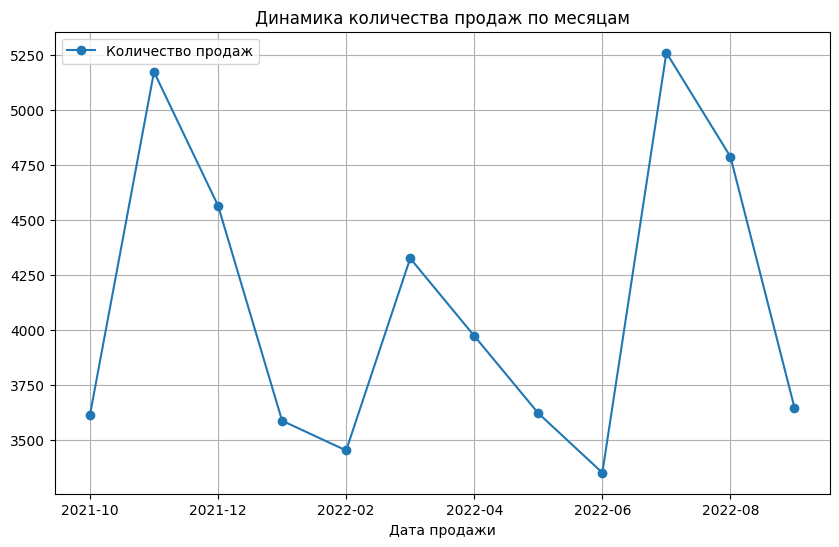

In [28]:
countrevenue = revenue.plot(xlabel='Дата продажи',
                            title='Динамика количества продаж по месяцам',
                            grid= True,
                            style='o-',
                            figsize=(10,6))

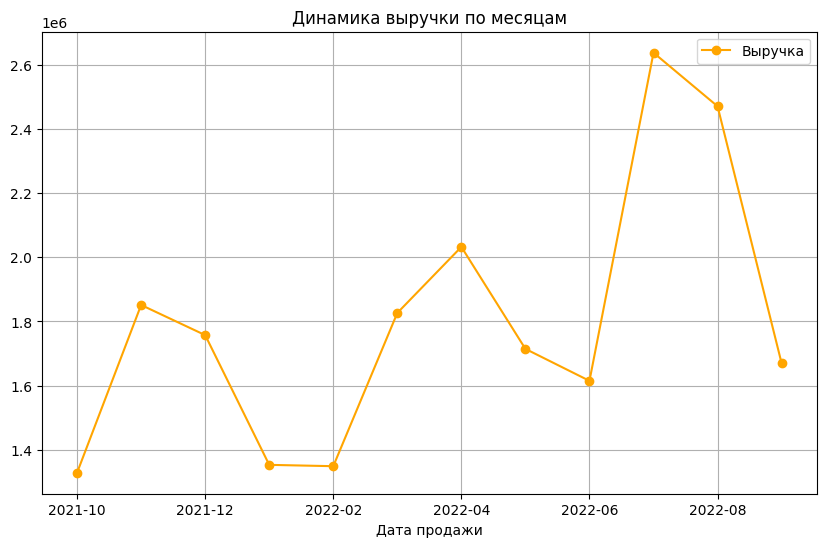

In [29]:
sumrevenue = sumr.plot(xlabel='Дата продажи',
                            title='Динамика выручки по месяцам',
                            grid= True,
                            style='o-',
                            color='orange',
                            figsize=(10,6))

#### Можем сделать вывод, что наибольшее число авиабилетов было продано в ноябре и в июле, а наибольшая выручка от продаж поступала в апреле и в июле. Это можно объяснить тем, что наплыв людей происходит перед новым годом и летом. В ноябре больше количество продаж , но меньше выручка, так как на новогодние праздники люди летают по менее популярным и дорогим направлениям( в основном, в родные города), чем летом. <br> Далее сгруппируем данные по количеству продаж в зависимости от наличия программы лояльности.

In [30]:
revenue1=df.pivot_table(index='year_month',
               columns='ffp_flag',
               aggfunc=['count'],
               values='revenue_amount').set_axis(['Есть программа лояльности','Нет программы лояльности'], axis='columns').rename_axis('Дата продажи')
revenue1

,Есть программа лояльности,Нет программы лояльности
Дата продажи,,
2021-10,1420,2195
2021-11,2161,3011
2021-12,1933,2632
2022-01,1507,2082
2022-02,1324,2130
2022-03,1913,2413
2022-04,1512,2462
2022-05,1400,2223
2022-06,1227,2126


In [31]:
#Также проанализируем динамику выручки
sumrevenue1=df.pivot_table(index='year_month',
               columns='ffp_flag',
               aggfunc=['sum'],
               values='revenue_amount').set_axis(['Есть программа лояльности','Нет программы лояльности'], axis='columns').rename_axis('Дата продажи')
sumrevenue1

,Есть программа лояльности,Нет программы лояльности
Дата продажи,,
2021-10,502030,825810
2021-11,735100,1116160
2021-12,721010,1036240
2022-01,538540,813850
2022-02,499240,848970
2022-03,801360,1025070
2022-04,764880,1267690
2022-05,649520,1064720
2022-06,590920,1023580


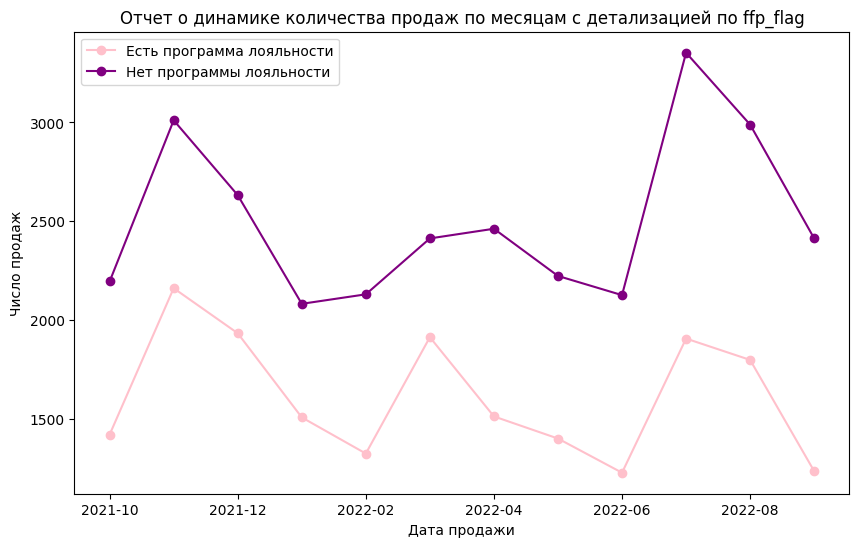

In [32]:
countrevenue1 = revenue1.plot(xlabel='Дата продажи',
                            ylabel='Число продаж',
                            title='Отчет о динамике количества продаж по месяцам с детализацией по ffp_flag',
                            color= ['pink','purple'],
                            style='o-',
                            figsize=(10,6))

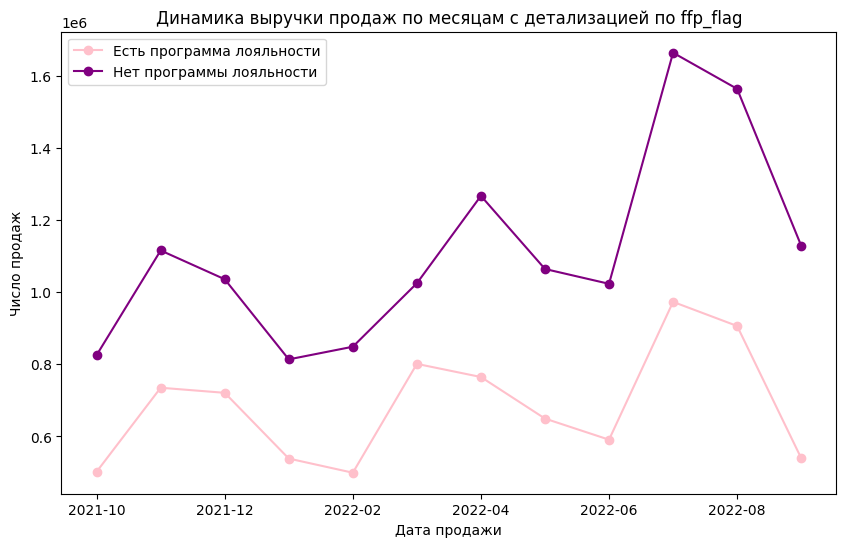

In [33]:
sumrevenue11 = sumrevenue1.plot(xlabel='Дата продажи',
                            ylabel='Число продаж',
                            title='Динамика выручки продаж по месяцам с детализацией по ffp_flag',
                            color= ['pink','purple'],
                            style='o-',
                            figsize=(10,6))

#### За весь, представленный в датасете период, количество проданных билетов, а следовательно и выручка, для лиц, у которых нет программмы лояльности, существенно превалирует.<br> Проанализируем количество проданных билетов и выручку международных и внутренних рейсов

In [34]:
revenue2=df.pivot_table(index='year_month',
               columns='route_flight_type',
               aggfunc='count',  
               values='revenue_amount').set_axis(['Внутренние Воздушные Линии','Международные Воздушные Линии'], axis='columns').rename_axis('Дата продажи')
revenue2

,Внутренние Воздушные Линии,Международные Воздушные Линии
Дата продажи,,
2021-10,3053,562
2021-11,4548,624
2021-12,3963,602
2022-01,3195,394
2022-02,3132,322
2022-03,4247,79
2022-04,3765,209
2022-05,3451,172
2022-06,3160,193


In [35]:
sumrevenue2=df.pivot_table(index='year_month',
               columns='route_flight_type',
               aggfunc='sum',  
               values='revenue_amount').set_axis(['Внутренние Воздушные Линии','Международные Воздушные Линии'], axis='columns').rename_axis('Дата продажи')
sumrevenue2

,Внутренние Воздушные Линии,Международные Воздушные Линии
Дата продажи,,
2021-10,1039020,288820
2021-11,1528990,322270
2021-12,1452480,304770
2022-01,1152790,199600
2022-02,1173370,174840
2022-03,1789040,37390
2022-04,1926430,106140
2022-05,1635180,79060
2022-06,1523810,90690


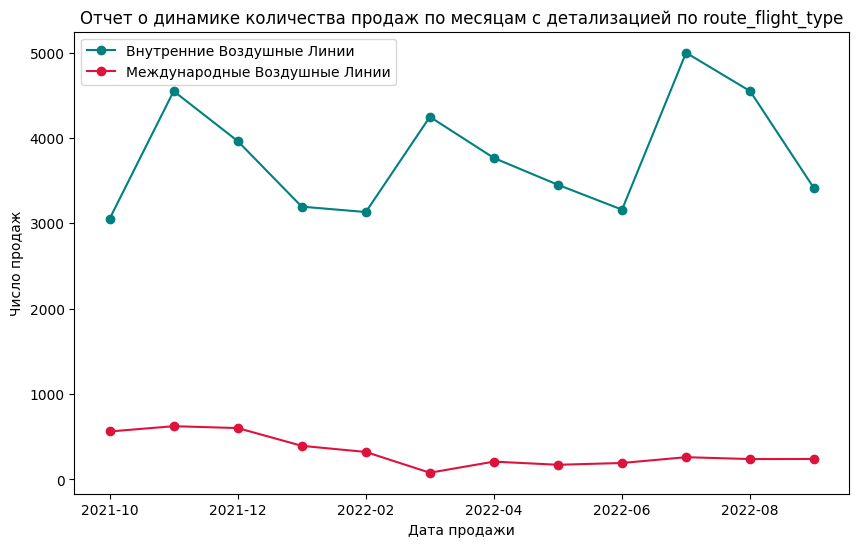

In [36]:
countrevenue2 = revenue2.plot(xlabel='Дата продажи',
                            ylabel='Число продаж',
                            title='Отчет о динамике количества продаж по месяцам с детализацией по route_flight_type',
                            color= ['teal','crimson'],
                            style='o-',
                            figsize=(10,6))

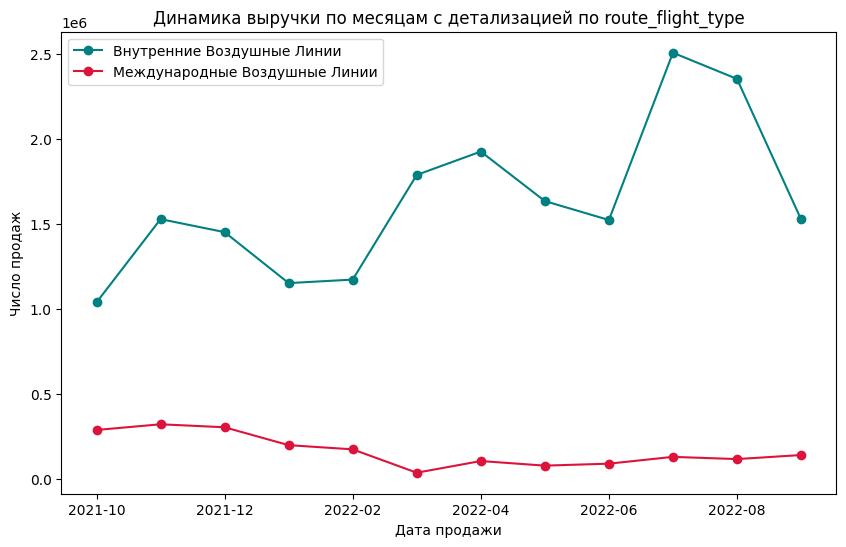

In [37]:
sumrevenue21 = sumrevenue2.plot(xlabel='Дата продажи',
                            ylabel='Число продаж',
                            title='Динамика выручки по месяцам с детализацией по route_flight_type',
                            color= ['teal','crimson'],
                            style='o-',
                            figsize=(10,6))

#### Судя по графику, было продано гораздо больше билетов на внутренние рейсы по Россси, чем международных за весь представленный в датасете период. Это может свзяно с тем, что билеты на внутренние рейсы дешевле. Тем не менее, выручка от продаж билетов на внутренние рейсы также превышает выручку от международных рейсов.

#### Проанализируем данные по продажам онлайн и оффлайн

In [38]:
revenue3=df.pivot_table(index='year_month',
               columns='sale_type',
               aggfunc='count',  
               values='revenue_amount').set_axis(['Offline','Online'], axis='columns').rename_axis('Дата продажи')
revenue3

,Offline,Online
Дата продажи,,
2021-10,1587,2028
2021-11,2238,2934
2021-12,1999,2566
2022-01,1489,2100
2022-02,1568,1886
2022-03,1719,2607
2022-04,1921,2053
2022-05,1439,2184
2022-06,1493,1860


In [39]:
sumrevenue3=df.pivot_table(index='year_month',
               columns='sale_type',
               aggfunc='sum',  
               values='revenue_amount').set_axis(['Offline','Online'], axis='columns').rename_axis('Дата продажи')
sumrevenue3

,Offline,Online
Дата продажи,,
2021-10,649640,678200
2021-11,901140,950120
2021-12,853050,904200
2022-01,623900,728490
2022-02,670260,677950
2022-03,796020,1030410
2022-04,1035090,997480
2022-05,744450,969790
2022-06,753650,860850


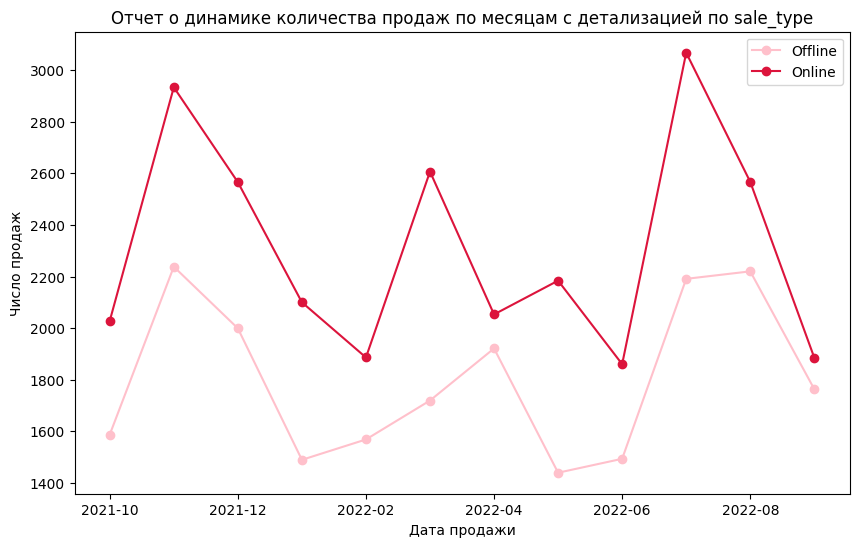

In [40]:
countrevenue3 = revenue3.plot(xlabel='Дата продажи',
                            ylabel='Число продаж',
                            title='Отчет о динамике количества продаж по месяцам с детализацией по sale_type',
                            color= ['pink','crimson'],
                            style='o-',
                            figsize=(10,6))

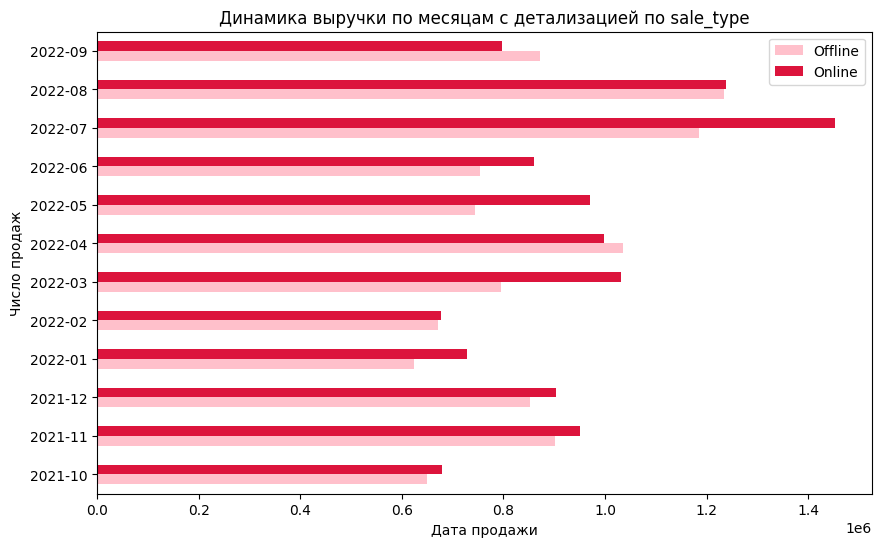

In [41]:
sumrevenue31 = sumrevenue3.plot(kind='barh',
                            xlabel='Дата продажи',
                            ylabel='Число продаж',
                            title='Динамика выручки по месяцам с детализацией по sale_type',
                            color= ['pink','crimson'],
                            style='o-',
                            figsize=(10,6))

#### По графику видно, что за весь, представленный в датасете период, большинство авиабилетов было продано онлайн в связи с удобством и доступностью оформления билета из любой точки мира. Однако, динамика выручки показывает различные соотношения этих двух групп в разные периоды времени.Чаще онлайн продажи превышали продажи оффлайн, но в сентябре и апреле можно увидеть противоположную динамику. <br> Сгруппируем данные по количеству продаж, выручке и среднему чеку с детализацией по возрасту пассажира

In [42]:
revenue4=df.pivot_table(index='pax_type',
                        aggfunc=['sum','count','mean'],  
                        values='revenue_amount').set_axis(['Взрослый','Ребенок','Неопределен'], axis='index').set_axis(['Выручка','Количество продаж','Средний чек'], axis='columns').rename_axis('Возраст')
revenue4

,Выручка,Количество продаж,Средний чек
Возраст,,,
Взрослый,20260530,45834,442.041498
Ребенок,1333430,3445,387.062409
Неопределен,9730,86,113.139535


[Text(3, 0, '2.02605e+07'), Text(3, 0, '1.33343e+06')]

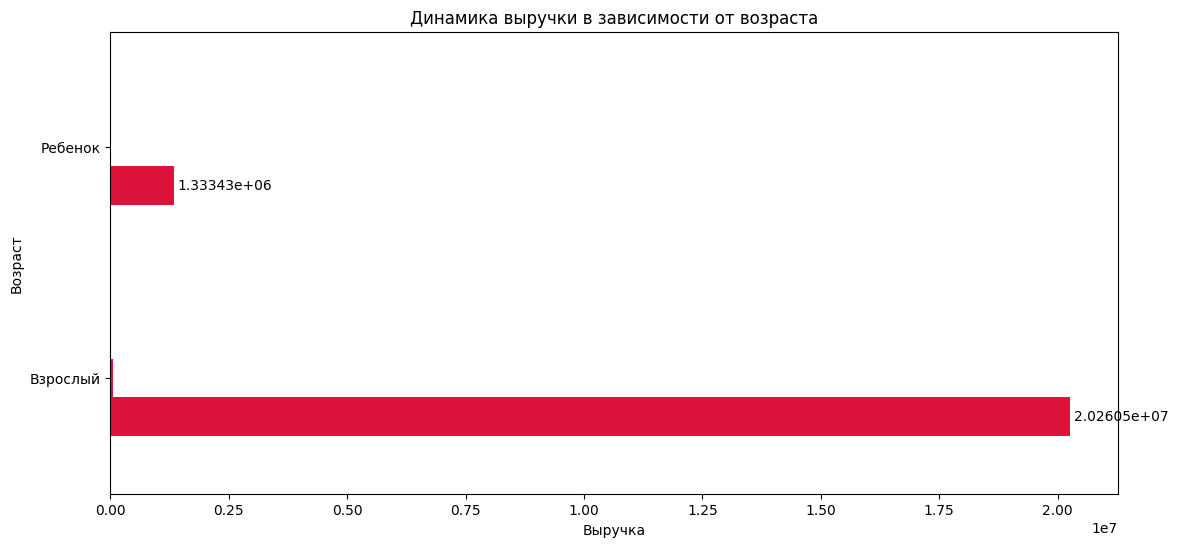

In [43]:
countrevenue4 = revenue4.sort_values('Выручка',ascending=False).head(2).plot(kind='barh',
                              xlabel='Выручка',
                              ylabel='Возраст',
                              title='Динамика выручки в зависимости от возраста',
                              color= ['crimson'],
                              figsize=(13,6),
                              legend=False)
countrevenue4.bar_label(countrevenue4.containers[0], padding=3)

#### Большинство авиабилетов было продано взрослым пассажирам, скорее всего, в связи с тем, что если билет покупают ребенку, то его чаще покупают и взрослому <br> Сгруппируем данные по общей выручке, количеству проданных авиабилетов и среднему чеку в зависимости от типа рейса

In [44]:
revenue5=df.pivot_table(index='route_flight_type',
                        aggfunc=['sum','count','mean'],  
                        values='revenue_amount').set_axis(['Внутренние воздушние линии','Международные воздушные линии'], axis='index').set_axis(['Выручка','Количество продаж','Средний чек'], axis='columns').rename_axis('Тип рейса')
revenue5

,Выручка,Количество продаж,Средний чек
Тип рейса,,,
Внутренние воздушние линии,19610480,45468,431.302894
Международные воздушные линии,1993210,3897,511.472928


[Text(0, 0, '1.96105e+07'), Text(0, 0, '1.99321e+06')]

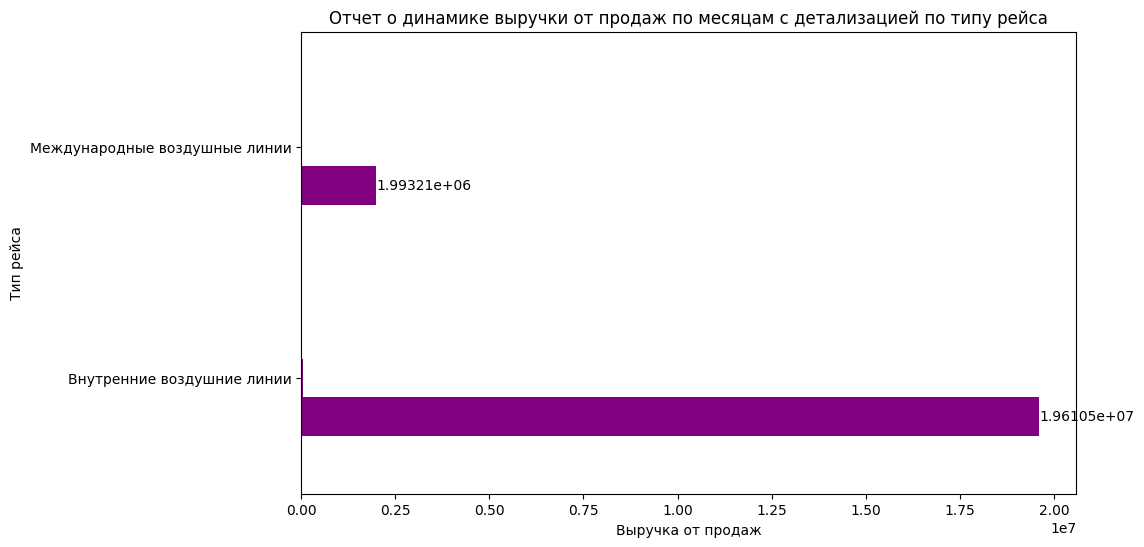

In [45]:
countrevenue5 = revenue5.plot(kind='barh',
                              xlabel='Выручка от продаж',
                              ylabel='Тип рейса',
                              title='Отчет о динамике выручки от продаж по месяцам с детализацией по типу рейса',
                              color='purple',
                              style='o-',
                              legend=False,
                              figsize=(10,6))
countrevenue5.bar_label(countrevenue5.containers[0],fontsize=10)

#### Таким образом, большинство авиабилетов (45 468 шт.) было продано на внутренние рейсы, а также выручка от них больше. Это связано с тем, что билет на внутренний рейс дешевле, чем на международный(средний чек на ВВЛ - 431.3, на МВЛ - 511.5) <br> Сгруппируем выручку, общее количество проданных авиабилетов и средний чек по способу покупки

In [46]:
revenue6=df.pivot_table(index='sale_type',
                        aggfunc=['sum','count','mean'],  
                        values='revenue_amount').set_axis(['Offline','Online'], axis='index').set_axis(['Выручка','Количество продаж','Средний чек'], axis='columns').rename_axis('Способ покупки')
revenue6

,Выручка,Количество продаж,Средний чек
Способ покупки,,,
Offline,10317780,21627,477.078652
Online,11285910,27738,406.875406


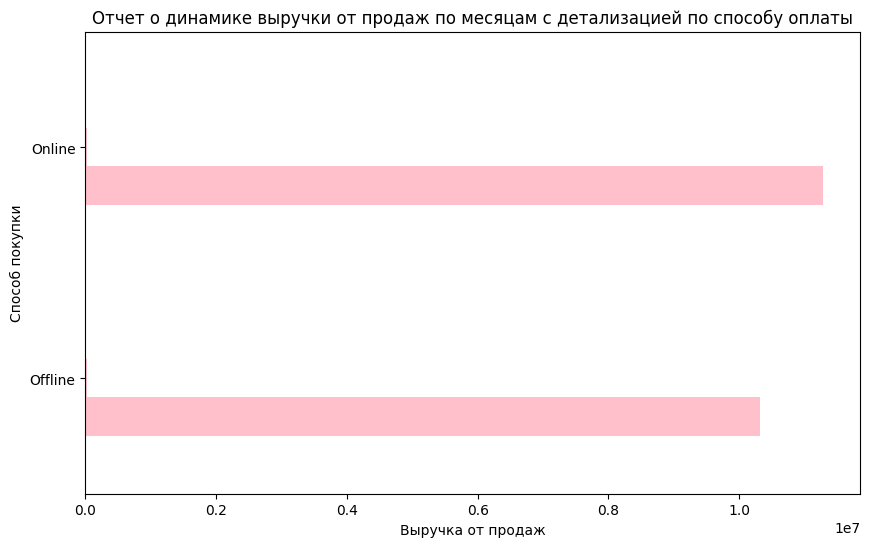

In [47]:
countrevenue6 = revenue6.plot(kind='barh',
                              xlabel='Выручка от продаж',
                              ylabel='Способ покупки',
                              title='Отчет о динамике выручки от продаж по месяцам с детализацией по способу оплаты',
                              color='pink',
                              style='o-',
                              legend=False,
                              figsize=(10,6))

#### Большинство авиабилетов было продано онлайн, что связано с удобством оформления билета, так как нет необходимости куда-то идти и стоять в очередях.Так же это связано с тем, что авиабилеты, купленные онлайн, обходятся клиентам дешевле по среднему чеку. <br> Визуализируем выручку, общее количество проданных билетов и средний чек в зависимости от наличия программы лояльности

In [48]:
revenue7=df.pivot_table(index='ffp_flag',
                        aggfunc=['sum','count','mean'], 
                        values='revenue_amount').set_axis(['Есть программа лояльности','Нет программы лояльности'], axis='index').set_axis(['Выручка','Количество продаж','Средний чек'], axis='columns').rename_axis('Наличие программы лояльности')
revenue7

,Выручка,Количество продаж,Средний чек
Наличие программы лояльности,,,
Есть программа лояльности,8222390,19336,425.237381
Нет программы лояльности,13381300,30029,445.612575


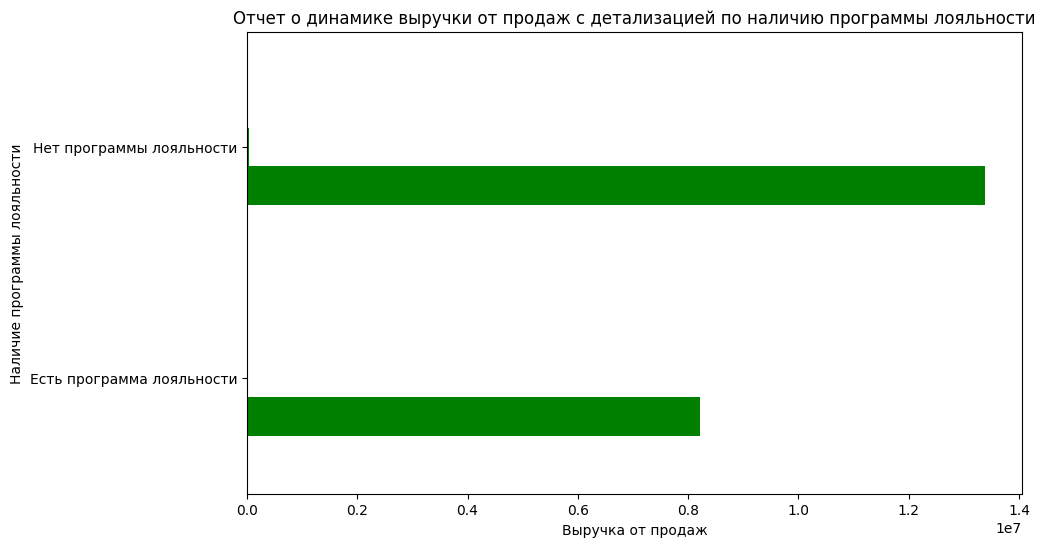

In [49]:
countrevenue7 = revenue7.plot(kind='barh',
                              xlabel='Выручка от продаж',
                              ylabel='Наличие программы лояльности',
                              title='Отчет о динамике выручки от продаж с детализацией по наличию программы лояльности',
                              color='green',
                              style='o-',
                              legend=False,
                              figsize=(10,6))

#### Можно сделать вывод, что большинство проданных авиабилетов были совершены клиентами без программы лояльности, несмотря на то , что при наличии программы лояльности билет обошелся бы дешевле( судя по среднему чеку от продаж)

###  <a class="anchor" id="10"></a> 3.2. Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.

In [50]:
df['revenue_amount'].describe()

count    49365.000000
mean       437.631723
std        214.604891
min         10.000000
25%        290.000000
50%        400.000000
75%        550.000000
max       5200.000000
Name: revenue_amount, dtype: float64

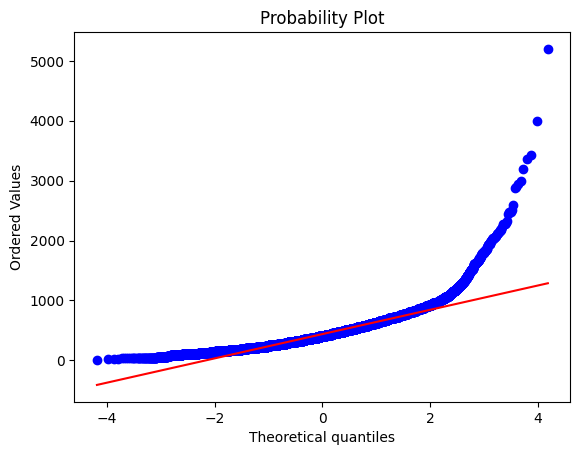

In [51]:
#Посмотрим на нормальность распределения
st.probplot(df['revenue_amount'], dist='norm', plot=plt)
plt.show()

#### Распределение не является нормальным, посмотрим, получится ли восстановить нормальность распределения при удалении выбросов.

<Axes: xlabel='year_month', ylabel='revenue_amount'>

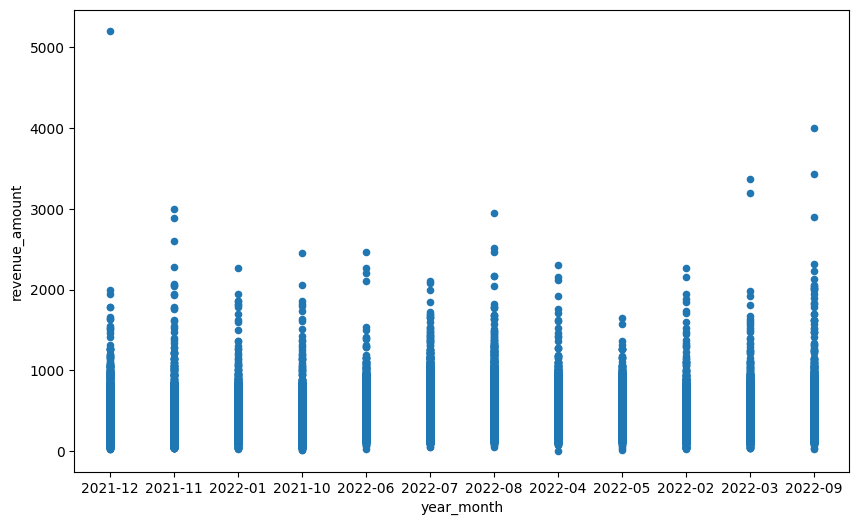

In [52]:
df.plot(kind='scatter',
          y='revenue_amount',
          x='year_month',
          figsize=(10, 6))

<Axes: >

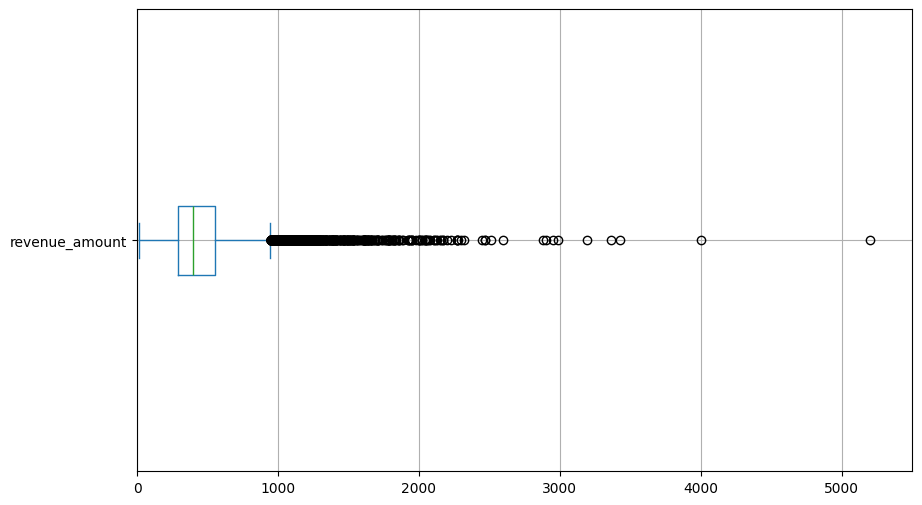

In [53]:
#Построим боксплот для проверки на выбросы
df['revenue_amount'].plot(kind='box', 
                     figsize=(10, 6), 
                     grid=True,
                     vert=False,
                     xlim=(0, 5500))

In [54]:
#Определим число выбросов по методу квартиелей
q75 = np.percentile(df['revenue_amount'], 75)
q25 = np.percentile(df['revenue_amount'], 25)
iqr = q75 - q25
ejection_h = q75+iqr*1.5 
ejection_l = q25-iqr*1.5
n_ejection = df['revenue_amount'][(df['revenue_amount'] > ejection_h) | (df['revenue_amount'] < ejection_l)].count()
print('Число выбросов:', n_ejection)

Число выбросов: 987


In [55]:
#Для минимизации потерь данных используем правило трех сигм, найдем среднее значение и стандартное отклонение
mean = df['revenue_amount'].mean()
std = df['revenue_amount'].std()
mean,std

(np.float64(437.6317228805834), np.float64(214.6048913560224))

In [56]:
# Границы по правилу 3 сигм
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

In [57]:
outliers = df[(df['revenue_amount'] < lower_bound) | (df['revenue_amount'] > upper_bound)]
#Число выбросов по правилу трех сигм
outliers_count = len(outliers)
outliers_count

464

In [58]:
#Процент выбросов по правилу трех сигм
outliers_count / len(df) * 100

0.9399372024713866

In [59]:
#Очистим датасет от выбросов
df1= df[(df['revenue_amount'] < upper_bound) & (df['revenue_amount'] > lower_bound)]
df1 = df1.reset_index(drop=True)

<Axes: >

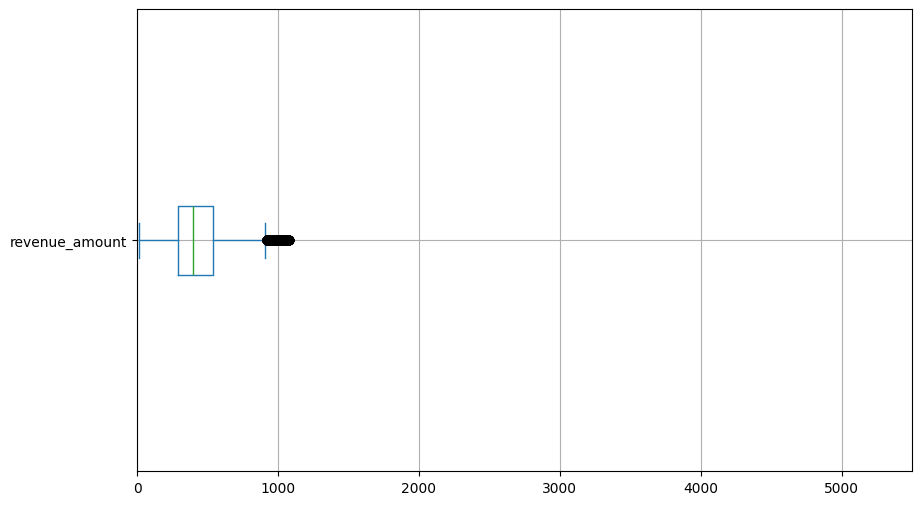

In [60]:
#Проверим
df1['revenue_amount'].plot(kind='box', 
                     figsize=(10, 6), 
                     grid=True,
                     vert=False,
                     xlim=(0, 5500))

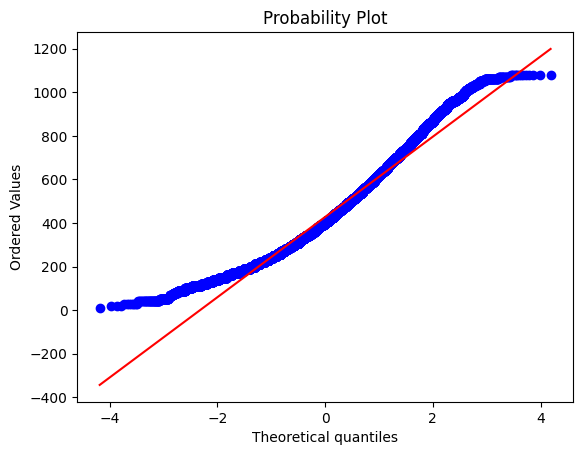

In [61]:
st.probplot(df1['revenue_amount'], dist='norm', plot=plt)
plt.show()

#### Таким образом, мы удалили 464 выброса по правилу трех сигм, и приблизились к нормальному распределению, но оно все еще не является нормальным.

###  <a class="anchor" id="11"></a> 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.

In [62]:
# Создаем словарь для сезонов
season_dict = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна', 
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

In [63]:
# Создадим столбец с месяцем и применим к нему словарь
df1['month'] = pd.DatetimeIndex(df1['issue_date']).month 

In [64]:
df1['season'] = df1['month'].map(season_dict)

In [65]:
df1

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year_month,month,season
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021-12,12,Зима
1,1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021-12,12,Зима
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,Осень
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,2021-12,12,Зима
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,Зима
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48896,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,2022-06,6,Лето
48897,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06,6,Лето
48898,49997,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,2022-06,6,Лето
48899,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06,6,Лето


In [66]:
season_revenue1 =df1.pivot_table(index='season', 
                                    aggfunc='count',  
                                    values='revenue_amount').set_axis(['Количество продаж'], axis='columns').rename_axis('Сезон продажи')
season_revenue1

,Количество продаж
Сезон продажи,
Весна,11849
Зима,11528
Лето,13204
Осень,12320


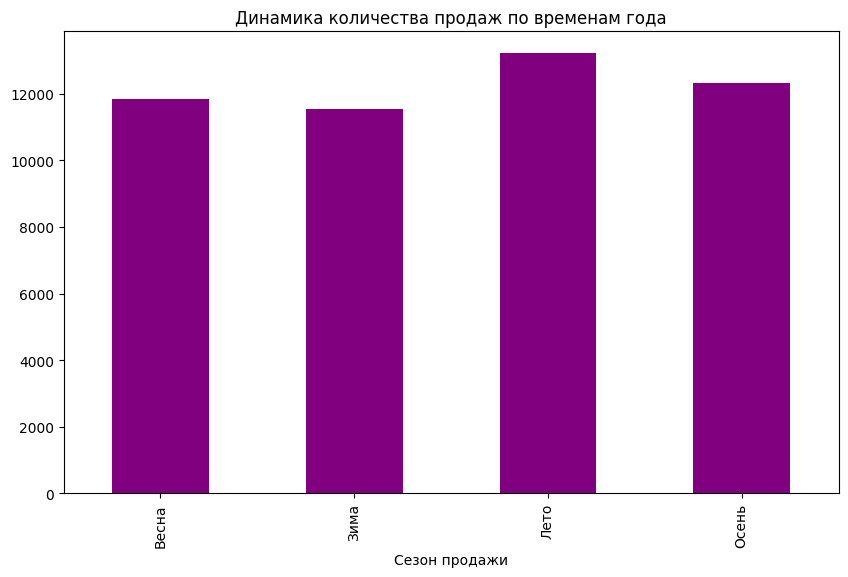

In [67]:
#Визуализируем с помощью столбчатой диаграммы
seasonrevenue_1 = season_revenue1.plot(kind='bar',
                            xlabel='Сезон продажи',
                            title='Динамика количества продаж по временам года',
                            color='purple',
                            legend=False,
                            style='o-',
                            figsize=(10,6))

In [68]:
season_revenue2 =df1.pivot_table(index='season', 
                                    aggfunc='mean',  
                                    values='revenue_amount').set_axis(['Средний чек'], axis='columns').rename_axis('Сезон продажи')
season_revenue2

,Средний чек
Сезон продажи,
Весна,461.433032
Зима,376.373178
Лето,489.288095
Осень,378.907468


[Text(0, 3, '461.433'),
 Text(0, 3, '376.373'),
 Text(0, 3, '489.288'),
 Text(0, 3, '378.907')]

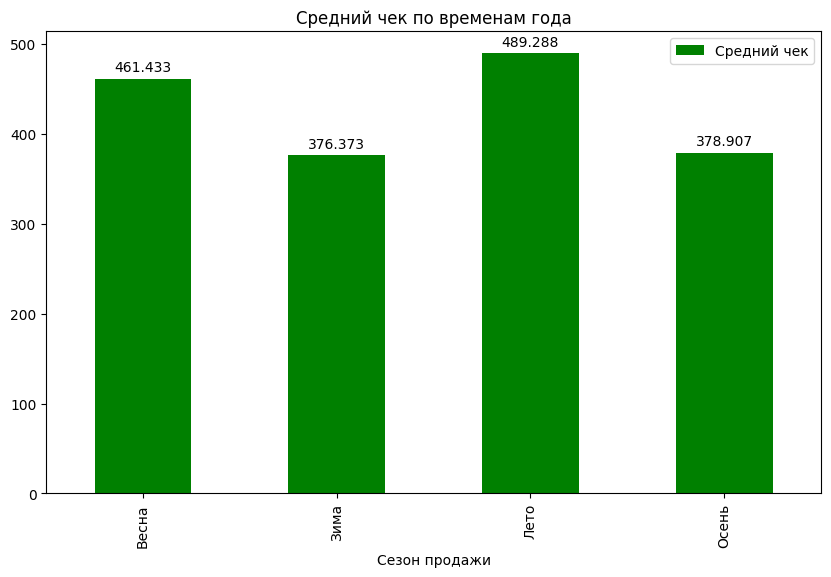

In [69]:
seasonrevenue_2 = season_revenue2.plot(kind='bar',
                            xlabel='Сезон продажи',
                            title='Средний чек по временам года',
                            color='green',
                            style='o-',
                            figsize=(10,6))
seasonrevenue_2.bar_label(seasonrevenue_2.containers[0], padding=3)

In [70]:
season_revenue3 =df1.pivot_table(index='season', 
                                    aggfunc='sum',  
                                    values='revenue_amount').set_axis(['Сумма продаж'], axis='columns').rename_axis('Сезон продажи')
season_revenue3

,Сумма продаж
Сезон продажи,
Весна,5467520
Зима,4338830
Лето,6460560
Осень,4668140


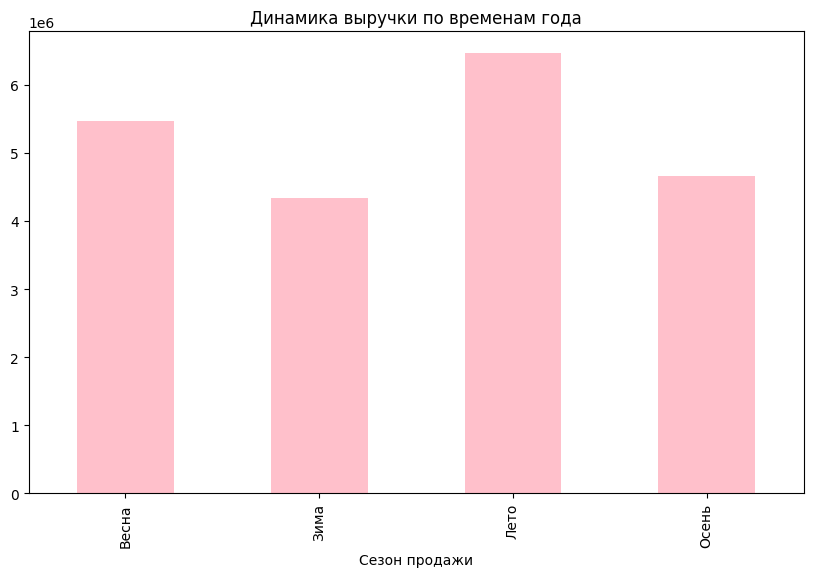

In [71]:
#столбчатая диаграмма
seasonrevenue4 = season_revenue3.plot(kind='bar',
                            xlabel='Сезон продажи',
                            title='Динамика выручки по временам года',
                            color='pink',
                            style='o-',
                            legend=False,
                            figsize=(10,6))

In [72]:
#Исследуем выручку и число продаж по месяцам
monthrev =df1.pivot_table(index='month', 
                                    aggfunc=['sum','count'],
                                    values='revenue_amount').set_axis(['Сумма выручки','Количество продаж'], axis='columns').rename_axis('Месяц продажи')
monthrev

,Сумма выручки,Количество продаж
Месяц продажи,,
1,1319160,3567
2,1310660,3428
3,1780900,4296
4,1991520,3945
5,1695100,3608
6,1579400,3328
7,2536990,5182
8,2344170,4694
9,1583100,3595


In [73]:
#Найдем корреляцию, используя коэффициент Спирмана для распределения, не являющегося нормальным
kf=monthrev.corr(method='spearman')
kf

,Сумма выручки,Количество продаж
Сумма выручки,1.000000,0.874126
Количество продаж,0.874126,1.000000


<Axes: >

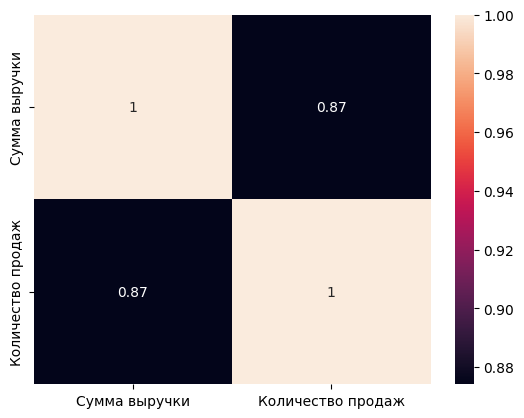

In [74]:
sns.heatmap(kf, annot=True)

##### Сумма выручки на 87% объясняется количеством продаж

Text(0.5, 1.0, 'Распределение выручки зимой')

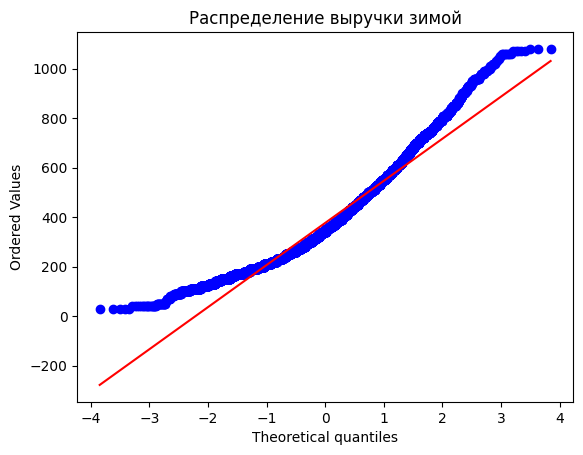

In [75]:
winter = df1.query('season == "Зима"')['revenue_amount']
autumn = df1.query('season == "Осень"')['revenue_amount']
from scipy import stats
stats.probplot(winter, dist="norm", plot=plt)
plt.title('Распределение выручки зимой')

Text(0.5, 1.0, 'Распределение выручки осенью')

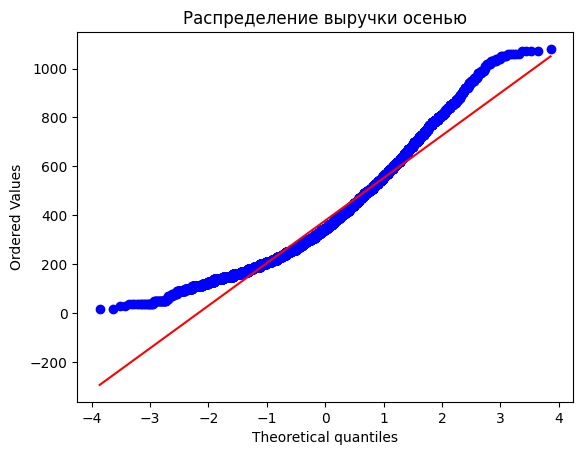

In [76]:
stats.probplot(autumn, dist="norm", plot=plt)
plt.title('Распределение выручки осенью')

##### Распределение выручки и осенью и зимой смещено право, так как хвост в правой части графики уходит наверх. Распределения не являются нормальными, рассмотрим выбросы с помощью боксплот.

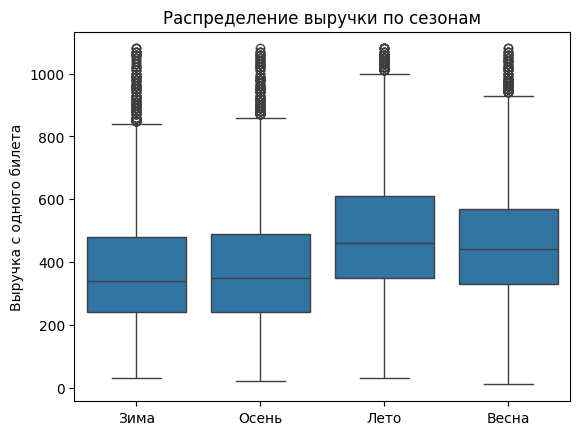

In [77]:
sns.boxplot(data=df1, x='season', y='revenue_amount')
plt.title('Распределение выручки по сезонам')
plt.ylabel('Выручка с одного билета')
plt.xlabel('')
plt.show()

#### Таким образом, больше всего авиабилетов продали летом и осенью, в следствие чего выручка от продаж также превалирует летом. Средний чек от продаж выше всего летом и весной, так как большинство людей улетают в отпуска летом, покупая билеты заранее весной и соответственно летом. <br> Для оценки различий выручки зимой и осенью, необходимо снова удалить выбросы в этих данных, так как их больше всего зимой и осенью. Выделим данные и удалим выбросы с помощью правила трех сигм.

In [78]:
df2 = df1.query('season == "Зима" or season=="Осень"') 

In [79]:
#Проведем повторную очистку данных
mean1 = df2['revenue_amount'].mean()
std1 = df2['revenue_amount'].std()
mean1,std1


(np.float64(377.68240523314324), np.float64(176.55346081162568))

In [80]:
lower_bound1 = mean1 - 3 * std1
upper_bound1 = mean1 + 3 * std1

In [81]:
outliers1 = df2[(df2['revenue_amount'] < lower_bound1) | (df2['revenue_amount'] > upper_bound1)]
#Число выбросов по правилу трех сигм
outliers_count1 = len(outliers1)
outliers_count1

210

In [82]:
#Очистим выбросы
df3 = df2[(df2['revenue_amount'] < upper_bound1) & (df2['revenue_amount'] > lower_bound1)]
df3 = df3.reset_index(drop=True)

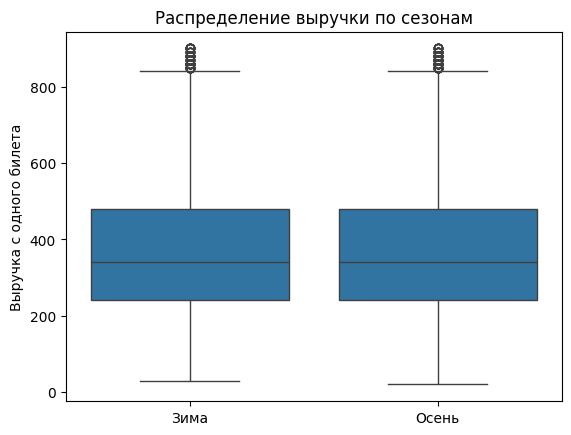

In [83]:
sns.boxplot(data=df3, x='season', y='revenue_amount')
plt.title('Распределение выручки по сезонам')
plt.ylabel('Выручка с одного билета')
plt.xlabel('')
plt.show()

#### По графику до повторной очистки от выбросов видно, что выручка зимой чуть меньше чем осенью, а после очистки визуально определить невозможно. Проверим гипотезу с df1 и df3: 
#### H0: Выручка от продаж осенью и зимой не отличается( для теста Уилкоксона-Манна-Уитни)
#### H0: Средняя выручка от продаж осенью и зимой не отличается (для t-теста)

In [84]:
 # Выделяем данные по осени и зиме
autumn_data = df1[df1['season'] == 'Осень']['revenue_amount']
winter_data = df1[df1['season'] == 'Зима']['revenue_amount']

In [85]:
print(np.mean(autumn_data))
print(np.mean(winter_data))

378.90746753246754
376.3731783483692


#### Используем ttest_ind

In [86]:
from scipy.stats import ttest_ind

In [87]:
t_stat, p_value = ttest_ind(autumn_data, winter_data, equal_var=False)

In [88]:
print(f"t-статистика: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

t-статистика: 1.1085
P-value: 0.267677


In [89]:
# Проверяем гипотезу
alpha = 0.05
if p_value < alpha:
    print(f'Отвергаем нулевую гипотезу: Средняя выручка осенью и зимой статистически значимо отличается (p < {alpha})')
else:
    print(f'Принимаем нулевую гипотезу: Нет статистически значимых различий между средней выручкой осенью и зимой (p ≥ {alpha})')

Принимаем нулевую гипотезу: Нет статистически значимых различий между средней выручкой осенью и зимой (p ≥ 0.05)


#### Так же проверим гипотезу, используя тест Уилкоксона-Манна-Уитни, так как распределение не является нормальным

In [90]:
from scipy import stats
alpha = 0.05
result = stats.mannwhitneyu(winter_data,autumn_data)
print('p-value:', result.pvalue)
if result.pvalue < alpha:
    print("Отвергаем H0: выручка от продаж зимой и осенью отличается")
else:
    print("Принимаем H0: выручка от продаж зимой и осенью не отличается")

p-value: 0.4543320649078262
Принимаем H0: выручка от продаж зимой и осенью не отличается


#### Проверим гипотезу с очищенными от выбросов данными

In [91]:
 # Выделяем данные по осени и зиме
autumn_data1 = df3[df3['season'] == 'Осень']['revenue_amount']
winter_data1 = df3[df3['season'] == 'Зима']['revenue_amount']
print(np.mean(autumn_data1))
print(np.mean(winter_data1))

373.3994102228047
371.19772528433947


In [92]:
#Используем ttest_ind
t_stat1, p_value1 = ttest_ind(autumn_data1, winter_data1, equal_var=False)
print(f"t-статистика: {t_stat1:.4f}")
print(f"P-value: {p_value1:.6f}")

t-статистика: 1.0083
P-value: 0.313301


In [93]:
# Проверяем гипотезу
alpha = 0.05
if p_value1 < alpha:
    print(f'Отвергаем нулевую гипотезу: Выручка осенью и зимой статистически значимо отличается (p < {alpha})')
else:
    print(f'Принимаем нулевую гипотезу: Нет статистически значимых различий между выручкой осенью и зимой (p ≥ {alpha})')

Принимаем нулевую гипотезу: Нет статистически значимых различий между выручкой осенью и зимой (p ≥ 0.05)


In [94]:
#Используем непараметрический тест Уилкоксона-Манна-Уитни
alpha = 0.05
result = stats.mannwhitneyu(winter_data1,autumn_data1)
print('p-value:', result.pvalue)
if result.pvalue < alpha:
    print("Отвергаем H0: выручка от продаж зимой и осенью отличается")
else:
    print("Принимаем H0: выручка от продаж зимой и осенью не отличается")

p-value: 0.49746587912003204
Принимаем H0: выручка от продаж зимой и осенью не отличается


#### Таким образом, нет статистически значимых различий между выручкой осенью зимой как до очистки данных от выбросов, так и после, т.е. выбросы не влияют на распределение выручки от продаж осенью и зимой.

###  <a class="anchor" id="12"></a> 3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы.

In [95]:
#Определим количество дней, за которое клиент купил билет перед вылетом
df1['days_before_flight'] = (df1['flight_date_loc'] - df1['issue_date']).dt.days

In [96]:
df1

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year_month,month,season,days_before_flight
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021-12,12,Зима,35
1,1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021-12,12,Зима,3
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,Осень,37
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,2021-12,12,Зима,28
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,Зима,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48896,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,2022-06,6,Лето,11
48897,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06,6,Лето,14
48898,49997,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,2022-06,6,Лето,3
48899,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06,6,Лето,2


In [97]:
df1['days_before_flight'].describe()

count    48901.000000
mean        20.997955
std         30.874205
min          0.000000
25%          3.000000
50%          9.000000
75%         25.000000
max        317.000000
Name: days_before_flight, dtype: float64

In [98]:
#Разделим клиентов на три группы, используя перцентили
days_25 = df1['days_before_flight'].describe()['25%']
days_75 = df1['days_before_flight'].describe()['75%']

In [99]:
def flying(days):
    
    if days <= days_25:
        return 'В последний момент'
    elif days_25 < days <= days_75:
        return 'Средний срок' 
    elif days_75 < days:
        return 'Заранее'
    else:
        return np.nan

In [100]:
df1['purchase_group'] = df1['days_before_flight'].apply(flying)
df1

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year_month,month,season,days_before_flight,purchase_group
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021-12,12,Зима,35,Заранее
1,1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021-12,12,Зима,3,В последний момент
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021-11,11,Осень,37,Заранее
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,2021-12,12,Зима,28,Заранее
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021-12,12,Зима,35,Заранее
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48896,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,2022-06,6,Лето,11,Средний срок
48897,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06,6,Лето,14,Средний срок
48898,49997,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,2022-06,6,Лето,3,В последний момент
48899,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,2022-06,6,Лето,2,В последний момент


##### Сгруппируем и визуализируем данные времени покупки билета , выручки, количества продаж и среднего чека

In [101]:
f=df1.pivot_table(index='purchase_group', 
                 aggfunc='sum',  
                 values='revenue_amount').set_axis(['Сумма продаж'], axis='columns').rename_axis('Количество дней до вылета')
f

,Сумма продаж
Количество дней до вылета,
В последний момент,5073250
Заранее,5218320
Средний срок,10643480


In [102]:
m=df1.pivot_table(index='purchase_group', 
                 aggfunc='mean',  
                 values='revenue_amount').set_axis(['Средний чек продаж'], axis='columns').rename_axis('Количество дней до вылета')
m

,Средний чек продаж
Количество дней до вылета,
В последний момент,413.737563
Заранее,440.364557
Средний срок,429.363024


In [103]:
b=df1.pivot_table(index='purchase_group', 
                 aggfunc='count',  
                 values='revenue_amount').set_axis(['Количество продаж'], axis='columns').rename_axis('Количество дней до вылета')
b


,Количество продаж
Количество дней до вылета,
В последний момент,12262
Заранее,11850
Средний срок,24789


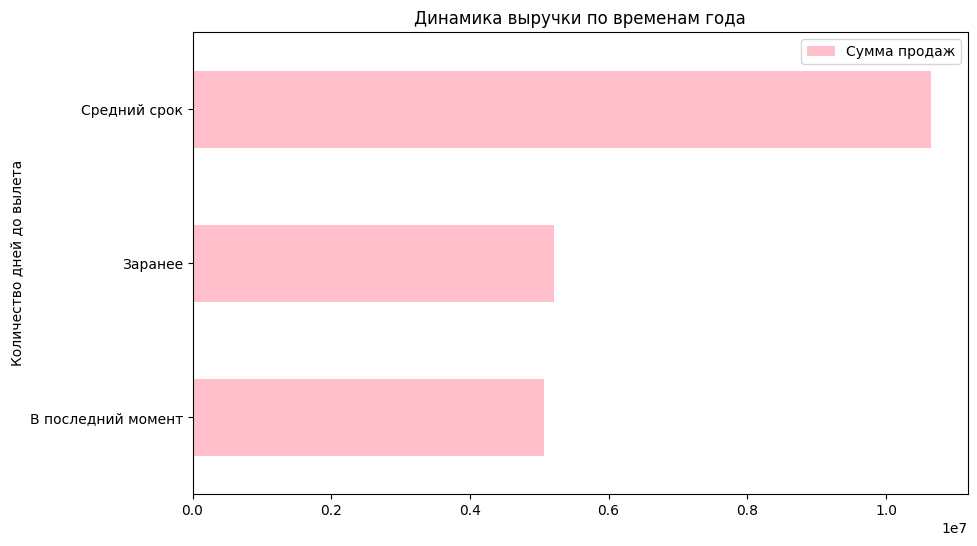

In [104]:
fplot = f.plot(kind='barh',
               title='Динамика выручки по временам года',
               color='pink',
               style='o-',
               figsize=(10,6))

In [105]:
#Выделим данные с выручкой тех, кто покупал билет заранее и в последний момент
sum1 = df1.query('purchase_group == "Заранее"')['revenue_amount']
sum2 = df1.query('purchase_group == "В последний момент"')['revenue_amount']

#### Проверим гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов не отличается с помощью теста Уилкоксона-Манна-Уитни

In [106]:
#Используем тест Уилкоксона-Манна-Уитни
from scipy.stats import mannwhitneyu 
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу
results = st.mannwhitneyu(sum1, sum2)
print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу') 
else:
    print('Не удалось отвергнуть нулевую гипотезу') 

p-value: 7.362273348387196e-48
Следует отвергнуть нулевую гипотезу


In [107]:
#Проверим гипотезу с помощью теста ttest_ind.
# H0: Средняя выручка от продажи билетов для билетов купленных в последний момент и билетов, купленных заранее не отличается
alpha= 0.05
results = st.ttest_ind(sum1,sum2)
print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу: средняя выручка от продаж для билетов купленных в последний момент и заранее отличается')
else:
    print('Принимаем нулевую гипотезу: средняя выручка от продаж для билетов купленных в последний момент и заранее не отличается')

p-value: 2.3285805798464055e-29
Следует отвергнуть нулевую гипотезу: средняя выручка от продаж для билетов купленных в последний момент и заранее отличается


#### Выручка от продаж для билетов, купленных в последний момент и заранее отличается статистически значимо. Большинство клиентов купили авиабилеты в средний срок покупки(за 3-25 дней). Чаще всего самые дешевые билеты остаются в последний момент (до 3 дней до вылета).


###  <a class="anchor" id="13"></a> 3.5. Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета:
     https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat

In [108]:
#Загружаем данные
url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
df_new = pd.read_csv(url, header=None)
df_new

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7693,14106,Rogachyovo Air Base,Belaya,Russia,\N,ULDA,71.616699,52.478298,272,\N,\N,\N,airport,OurAirports
7694,14107,Ulan-Ude East Airport,Ulan Ude,Russia,\N,XIUW,51.849998,107.737999,1670,\N,\N,\N,airport,OurAirports
7695,14108,Krechevitsy Air Base,Novgorod,Russia,\N,ULLK,58.625000,31.385000,85,\N,\N,\N,airport,OurAirports
7696,14109,Desierto de Atacama Airport,Copiapo,Chile,CPO,SCAT,-27.261200,-70.779198,670,\N,\N,\N,airport,OurAirports


In [109]:
#Создадим названия для столбцов
df_new.columns = ['ID','airport_name','location','country','iata','icao','latitude','longitude','altitude','timezone','dst','timezone_reg','type','source']
df_new

,ID,airport_name,location,country,iata,icao,latitude,longitude,altitude,timezone,dst,timezone_reg,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7693,14106,Rogachyovo Air Base,Belaya,Russia,\N,ULDA,71.616699,52.478298,272,\N,\N,\N,airport,OurAirports
7694,14107,Ulan-Ude East Airport,Ulan Ude,Russia,\N,XIUW,51.849998,107.737999,1670,\N,\N,\N,airport,OurAirports
7695,14108,Krechevitsy Air Base,Novgorod,Russia,\N,ULLK,58.625000,31.385000,85,\N,\N,\N,airport,OurAirports
7696,14109,Desierto de Atacama Airport,Copiapo,Chile,CPO,SCAT,-27.261200,-70.779198,670,\N,\N,\N,airport,OurAirports


In [110]:
# Оставляем только нужные столбцы
cities_cod = df_new[['iata', 'location','latitude','longitude']]
# Для города вылета
cities_cod_orig = cities_cod.rename(columns={'iata': 'orig_city_code', 'location': 'orig_city_name','latitude':'orig_latitude','longitude' : 'orig_longitude'})
df1 = df1.merge(cities_cod_orig, on='orig_city_code', how='left')
# Для города назначения  
cities_cod_dest = cities_cod.rename(columns={'iata': 'dest_city_code', 'location': 'dest_city_name','latitude':'dest_latitude','longitude' : 'dest_longitude'})
df1 = df1.merge(cities_cod_dest, on='dest_city_code', how='left')

In [111]:
df1

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,...,month,season,days_before_flight,purchase_group,orig_city_name,orig_latitude,orig_longitude,dest_city_name,dest_latitude,dest_longitude
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,...,12,Зима,35,Заранее,NaN,NaN,NaN,Kaliningrad,54.889999,20.592600
1,1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,...,12,Зима,3,В последний момент,Yuzhno-sakhalinsk,46.888699,142.718002,Novosibirsk,55.012600,82.650703
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,...,11,Осень,37,Заранее,Kaliningrad,54.889999,20.592600,NaN,NaN,NaN
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,...,12,Зима,28,Заранее,Voronezh,51.814201,39.229599,NaN,NaN,NaN
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,...,12,Зима,35,Заранее,NaN,NaN,NaN,Krasnodar,45.034698,39.170502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48896,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,...,6,Лето,11,Средний срок,NaN,NaN,NaN,Omsk,54.966999,73.310501
48897,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,14,Средний срок,St. Petersburg,59.800301,30.262501,NaN,NaN,NaN
48898,49997,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,...,6,Лето,3,В последний момент,NaN,NaN,NaN,Kazan,55.606201,49.278702
48899,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,2,В последний момент,Kazan,55.606201,49.278702,NaN,NaN,NaN


#### Обработаем пропущенные значения в столбцах orig_city_name и dest_city_name

In [112]:
df1.isna().sum()

index                     0
issue_date                0
flight_date_loc           0
pax_type                  0
revenue_amount            0
orig_city_code            0
dest_city_code            0
route_flight_type         0
ffp_flag                  0
sale_type                 0
year_month                0
month                     0
season                    0
days_before_flight        0
purchase_group            0
orig_city_name        16047
orig_latitude         16047
orig_longitude        16047
dest_city_name        16172
dest_latitude         16172
dest_longitude        16172
dtype: int64

In [113]:
df1[df1['orig_city_name'].isna()]

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,...,month,season,days_before_flight,purchase_group,orig_city_name,orig_latitude,orig_longitude,dest_city_name,dest_latitude,dest_longitude
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,...,12,Зима,35,Заранее,NaN,NaN,NaN,Kaliningrad,54.889999,20.592600
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,...,12,Зима,35,Заранее,NaN,NaN,NaN,Krasnodar,45.034698,39.170502
5,5,2021-11-29,2022-01-14,AD,250,MOW,DUS,МВЛ,NO_FFP,ONLINE,...,11,Осень,46,Заранее,NaN,NaN,NaN,Duesseldorf,51.289501,6.766780
6,6,2021-12-03,2022-01-06,AD,200,MOW,PEE,ВВЛ,FFP,ONLINE,...,12,Зима,34,Заранее,NaN,NaN,NaN,Perm,57.914501,56.021198
7,7,2021-11-28,2022-01-07,CHD,70,MOW,AER,ВВЛ,FFP,ONLINE,...,11,Осень,40,Заранее,NaN,NaN,NaN,Sochi,43.449902,39.956600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48882,49981,2022-06-27,2022-06-29,AD,290,MOW,KUF,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,2,В последний момент,NaN,NaN,NaN,Samara,53.504902,50.164299
48892,49991,2022-06-15,2022-06-16,AD,260,MOW,UFA,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,1,В последний момент,NaN,NaN,NaN,Ufa,54.557499,55.874401
48893,49992,2022-06-22,2022-06-28,AD,810,MOW,BTK,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,6,Средний срок,NaN,NaN,NaN,Bratsk,56.370602,101.697998
48896,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,...,6,Лето,11,Средний срок,NaN,NaN,NaN,Omsk,54.966999,73.310501


In [114]:
df1[df1['dest_city_name'].isna()]

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,...,month,season,days_before_flight,purchase_group,orig_city_name,orig_latitude,orig_longitude,dest_city_name,dest_latitude,dest_longitude
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,...,11,Осень,37,Заранее,Kaliningrad,54.889999,20.592600,NaN,NaN,NaN
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,...,12,Зима,28,Заранее,Voronezh,51.814201,39.229599,NaN,NaN,NaN
12,12,2021-12-08,2022-01-03,AD,210,KZN,MOW,ВВЛ,NO_FFP,ONLINE,...,12,Зима,26,Заранее,Kazan,55.606201,49.278702,NaN,NaN,NaN
13,14,2021-12-03,2022-01-14,AD,370,UUD,MOW,ВВЛ,FFP,ONLINE,...,12,Зима,42,Заранее,Ulan-ude,51.807800,107.438004,NaN,NaN,NaN
14,16,2021-12-03,2022-01-20,AD,470,TAS,MOW,МВЛ,NO_FFP,OFFLINE,...,12,Зима,48,Заранее,Tashkent,41.257900,69.281197,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48891,49990,2022-06-27,2022-06-28,AD,370,OMS,MOW,ВВЛ,FFP,ONLINE,...,6,Лето,1,В последний момент,Omsk,54.966999,73.310501,NaN,NaN,NaN
48894,49993,2022-06-20,2022-06-21,AD,520,MCX,MOW,ВВЛ,FFP,ONLINE,...,6,Лето,1,В последний момент,Makhachkala,42.816799,47.652302,NaN,NaN,NaN
48897,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,14,Средний срок,St. Petersburg,59.800301,30.262501,NaN,NaN,NaN
48899,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,2,В последний момент,Kazan,55.606201,49.278702,NaN,NaN,NaN


##### Столбцы orig_city_code и dest_city_code напрямую связаны со столбцами orig_city_name и dest_city_name, заполним пропуски названий городов в соответствие с их кодами аэропортов, а затем заменим коды на названия с помощью словаря

In [115]:
df1['orig_city_name'] = df1['orig_city_name'].fillna(df1['orig_city_code'])

In [116]:
df1['dest_city_name'] = df1['dest_city_name'].fillna(df1['dest_city_code'])

In [117]:
df1['orig_city_name'].unique()

array(['MOW', 'Yuzhno-sakhalinsk', 'Kaliningrad', 'Voronezh',
       'Novosibirsk', 'Kazan', 'Ulan-ude', 'Tashkent', 'Yekaterinburg',
       'Omsk', 'St. Petersburg', 'Beslan', 'Sochi', 'Belgorod',
       'Krasnodar', 'Kemorovo', 'Samara', 'Khudzhand', 'Novy Urengoy',
       'Irkutsk', 'Bourgas', 'Dubai', 'Krasnoyarsk', 'Anapa', 'Tomsk',
       'Lipetsk', 'Surgut', 'Antalya', 'Hurghada', 'Ufa', 'Varna',
       'Mirnyj', 'Gelendzhik', 'Simferopol', 'Rostov', 'Bangkok',
       'Murmansk', 'Chisinau', 'PAR', 'Bratsk', 'Apatity', 'Perm',
       'Saratov', 'Neryungri', 'Novokuznetsk', 'Makhachkala',
       'Nizhniy Novgorod', 'Nizhnevartovsk', 'Magnetiogorsk',
       'Sharm El Sheikh', 'Yakutsk', 'Blagoveschensk', 'Ivanovo',
       'Vladivostok', 'Petropavlovsk', 'Abakan', 'Noyabrsk',
       'Chelyabinsk', 'Phuket', 'Penza', 'BAK', 'Volgograd', 'Ulyanovsk',
       'Talakan', 'Norilsk', 'Khanabad', 'Kurgan Tyube', 'Munich',
       'Fergana', 'ROM', 'Alma-ata', 'Mineralnye Vody', 'Chita',
   

In [118]:
df1['dest_city_name'].unique()

array(['Kaliningrad', 'Novosibirsk', 'MOW', 'Krasnodar', 'Duesseldorf',
       'Perm', 'Sochi', 'Nizhnevartovsk', 'Samara', 'Ulan-ude',
       'Helsinki', 'St. Petersburg', 'Abakan', 'Yerevan', 'Gelendzhik',
       'Kazan', 'Mineralnye Vody', 'Simferopol', 'Thessaloniki',
       'Fergana', 'Magnetiogorsk', 'Volgograd', 'Phuket', 'Chelyabinsk',
       'Saratov', 'Irkutsk', 'Ulyanovsk', 'Novy Urengoy', 'Tomsk',
       'Dubai', 'Yakutsk', 'Yuzhno-sakhalinsk', 'Blagoveschensk',
       'Yekaterinburg', 'Petropavlovsk', 'Surgut', 'Izhevsk', 'Beslan',
       'Anapa', 'Murmansk', 'Krasnoyarsk', 'Khabarovsk', 'Chisinau',
       'Novokuznetsk', 'BAK', 'Ufa', 'Cologne', 'Rostov', 'Neryungri',
       'Belgorod', 'Kemorovo', 'Talakan', 'Vienna', 'Barnaul', 'Penza',
       'Chita', 'Stavropol', 'Magadan', 'Vladivostok', 'Antalya',
       'Gorno-Altaysk', 'Villafranca', 'Tashkent', 'Bologna', 'Bratsk',
       'Norilsk', 'Osh', 'Nizhniy Novgorod', 'Astrakhan',
       'Sharm El Sheikh', 'Dushanbe', 'Om

In [119]:
#Создадим словарь с соответствиями замененных кодов на названия городов
city_codes_dict = {
    'MOW': 'Moscow',
    'ROM': 'Rome',
    'BAK': 'Baku',
    'SEL': 'Seoul',
    'PAR': 'Paris',
    'BER': 'Berlin',
    'GRV': 'Grozny',
    'NQZ': 'Nur-Sultan',
    'OHH': 'Okha',
    'TOX': 'Tobolsk',
    'MIL': 'Milan',
    'TYO': 'Tokyo',
    'LON': 'London'
}

In [120]:
#Применим словарь к датасету
df1['orig_city_name'] = df1['orig_city_name'].replace(city_codes_dict)
df1['dest_city_name'] = df1['dest_city_name'].replace(city_codes_dict)

In [121]:
df1

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,...,month,season,days_before_flight,purchase_group,orig_city_name,orig_latitude,orig_longitude,dest_city_name,dest_latitude,dest_longitude
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,...,12,Зима,35,Заранее,Moscow,NaN,NaN,Kaliningrad,54.889999,20.592600
1,1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,...,12,Зима,3,В последний момент,Yuzhno-sakhalinsk,46.888699,142.718002,Novosibirsk,55.012600,82.650703
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,...,11,Осень,37,Заранее,Kaliningrad,54.889999,20.592600,Moscow,NaN,NaN
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,...,12,Зима,28,Заранее,Voronezh,51.814201,39.229599,Moscow,NaN,NaN
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,...,12,Зима,35,Заранее,Moscow,NaN,NaN,Krasnodar,45.034698,39.170502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48896,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,...,6,Лето,11,Средний срок,Moscow,NaN,NaN,Omsk,54.966999,73.310501
48897,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,14,Средний срок,St. Petersburg,59.800301,30.262501,Moscow,NaN,NaN
48898,49997,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,...,6,Лето,3,В последний момент,Moscow,NaN,NaN,Kazan,55.606201,49.278702
48899,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,...,6,Лето,2,В последний момент,Kazan,55.606201,49.278702,Moscow,NaN,NaN


In [122]:
#Для удобства визуализации маршрутов создадим новый столбец с маршрутом через дефис
df1['route'] = df1['orig_city_name'] + ' - ' + df1['dest_city_name']
df1

,index,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,...,season,days_before_flight,purchase_group,orig_city_name,orig_latitude,orig_longitude,dest_city_name,dest_latitude,dest_longitude,route
0,0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,...,Зима,35,Заранее,Moscow,NaN,NaN,Kaliningrad,54.889999,20.592600,Moscow - Kaliningrad
1,1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,...,Зима,3,В последний момент,Yuzhno-sakhalinsk,46.888699,142.718002,Novosibirsk,55.012600,82.650703,Yuzhno-sakhalinsk - Novosibirsk
2,2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,...,Осень,37,Заранее,Kaliningrad,54.889999,20.592600,Moscow,NaN,NaN,Kaliningrad - Moscow
3,3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,...,Зима,28,Заранее,Voronezh,51.814201,39.229599,Moscow,NaN,NaN,Voronezh - Moscow
4,4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,...,Зима,35,Заранее,Moscow,NaN,NaN,Krasnodar,45.034698,39.170502,Moscow - Krasnodar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48896,49995,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,...,Лето,11,Средний срок,Moscow,NaN,NaN,Omsk,54.966999,73.310501,Moscow - Omsk
48897,49996,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,...,Лето,14,Средний срок,St. Petersburg,59.800301,30.262501,Moscow,NaN,NaN,St. Petersburg - Moscow
48898,49997,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,...,Лето,3,В последний момент,Moscow,NaN,NaN,Kazan,55.606201,49.278702,Moscow - Kazan
48899,49998,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,...,Лето,2,В последний момент,Kazan,55.606201,49.278702,Moscow,NaN,NaN,Kazan - Moscow


In [123]:
#Выделяем и визуализируем данные
vvl=df1.query('route_flight_type == "ВВЛ"')
mvl=df1.query('route_flight_type == "МВЛ"')

In [124]:
top10vvl=vvl.pivot_table(index='route',
               aggfunc=['sum','count','mean'],  
               values='revenue_amount').set_axis(['Выручка','Количество продаж','Средний чек'], axis='columns').rename_axis('Маршрут')
top10vvl.sort_values('Выручка', ascending=False).head(10)

,Выручка,Количество продаж,Средний чек
Маршрут,,,
Sochi - Moscow,517870,1330,389.375940
Moscow - Sochi,489410,1301,376.179862
Novosibirsk - Moscow,460720,967,476.442606
Moscow - Novosibirsk,441520,945,467.216931
Novosibirsk - Sochi,389360,675,576.829630
Sochi - Novosibirsk,355510,601,591.530782
Novosibirsk - St. Petersburg,284780,586,485.972696
St. Petersburg - Moscow,280870,1211,231.932287
Moscow - St. Petersburg,275790,1192,231.367450


<Axes: title={'center': 'Топ-10 ВВЛ маршрутов по выручке'}, xlabel='Выручка', ylabel='Направление'>

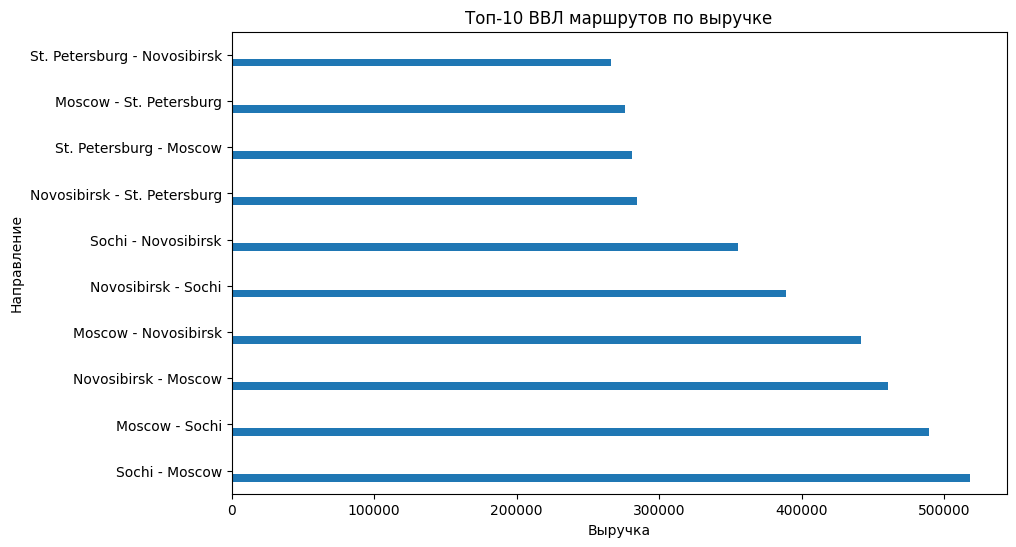

In [125]:
#Сделаем визуализацию
top10vvl.sort_values('Выручка', ascending=False).head(10).plot(kind='barh',
                  xlabel='Выручка',
                  ylabel='Направление',
                  title='Топ-10 ВВЛ маршрутов по выручке',
                  style='o-',
                  legend= False,
                  figsize=(10,6))

<Axes: title={'center': 'Топ-10 ВВЛ маршрутов по количеству продаж'}, xlabel='Количество продаж', ylabel='Направление'>

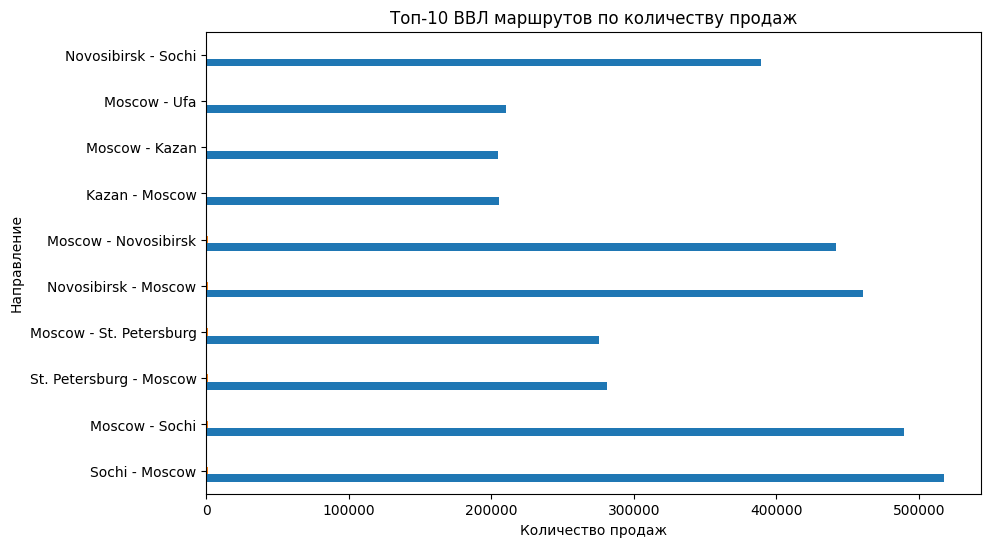

In [126]:
top10vvl.sort_values('Количество продаж', ascending=False).head(10).plot(kind='barh',
                  xlabel='Количество продаж',
                  ylabel='Направление',
                  title='Топ-10 ВВЛ маршрутов по количеству продаж',
                  style='o-',
                  legend= False,
                  figsize=(10,6))

In [127]:
top10mvl=mvl.pivot_table(index='route',
               aggfunc=['sum','count','mean'],  
               values='revenue_amount').set_axis(['Выручка','Количество продаж','Средний чек'], axis='columns').rename_axis('Маршрут')
top10mvl.sort_values('Выручка', ascending=False).head(10)

,Выручка,Количество продаж,Средний чек
Маршрут,,,
Khudzhand - Moscow,97160,146,665.479452
Osh - Moscow,80920,136,595.000000
Moscow - Osh,69160,152,455.000000
Moscow - Khudzhand,58750,130,451.923077
Osh - Novosibirsk,57970,116,499.741379
Khudzhand - Novosibirsk,57740,116,497.758621
Bishkek - Novosibirsk,48300,102,473.529412
Novosibirsk - Osh,47450,119,398.739496
Novosibirsk - Bishkek,46980,120,391.500000


<Axes: title={'center': 'Топ-10 МВЛ маршрутов по выручке'}, xlabel='Выручка', ylabel='Направление'>

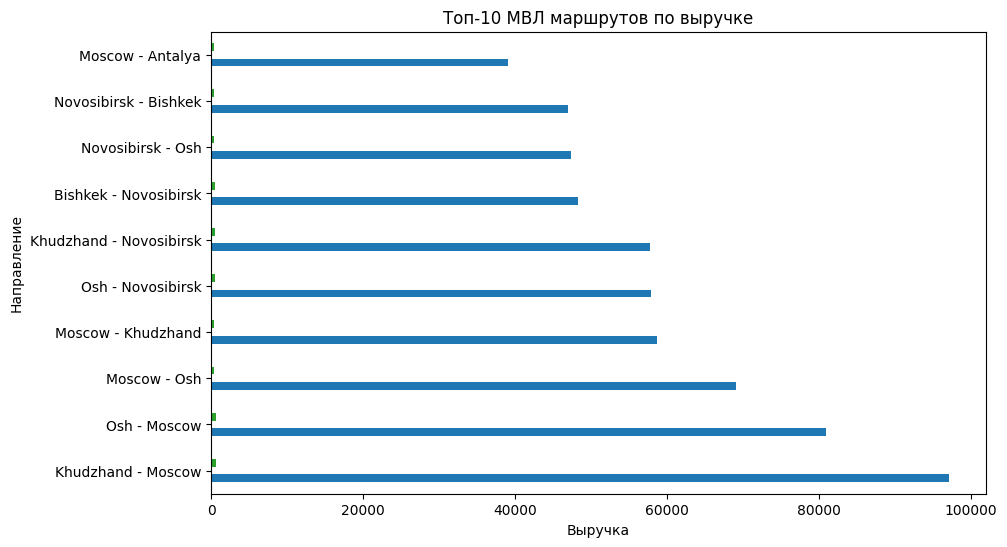

In [128]:
top10mvl.sort_values('Выручка', ascending=False).head(10).plot(kind='barh',
                  xlabel='Выручка',
                  ylabel='Направление',
                  title='Топ-10 МВЛ маршрутов по выручке',
                  legend= False,
                  figsize=(10,6))

<Axes: title={'center': 'Топ-10 МВЛ маршрутов по количеству продаж'}, xlabel='Выручка', ylabel='Направление'>

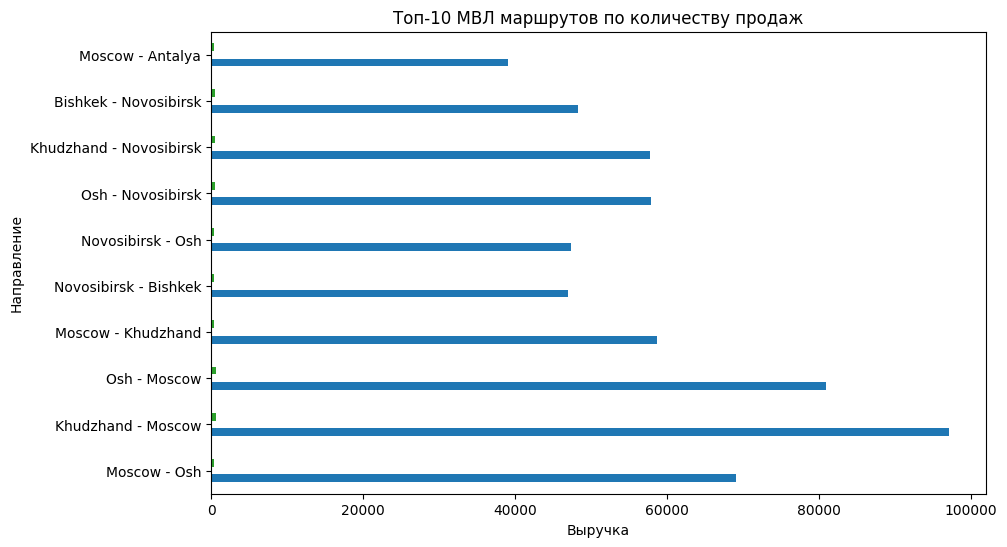

In [129]:
top10mvl.sort_values('Количество продаж', ascending=False).head(10).plot(kind='barh',
                  xlabel='Выручка',
                  ylabel='Направление',
                  title='Топ-10 МВЛ маршрутов по количеству продаж',
                  legend= False,
                  figsize=(10,6))

#### Можно сделать вывод, что самый популярный маршрут по внутренним рейсам по количеству продаж и по выручке - Сочи-Москва. Это объясняется тем, что в Москве проживает около 13 миллионов человек, а Сочи - самый популярный отечестенный город-курорт. Самый популярный маршрут по международним рейсам как по количеству продаж, так и по сумме выручки - "Москва-Ош". Это можно объяснить высоким числом мигрантов в России, в частности в Москве.

###  <a class="anchor" id="14"></a> 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

In [130]:
#Создадим бинарные переменные для матрицы корреляций
df1['ffp_numeric'] = df1['ffp_flag'].map({'FFP': 1, 'NO_FFP': 0})
df1['is_international'] = (df1['route_flight_type'] == 'МВЛ').astype(int)
df1['is_domestic'] = (df1['route_flight_type'] == 'ВВЛ').astype(int)
df1['is_online'] = (df1['sale_type'] == 'ONLINE').astype(int)
df1['is_offline'] = (df1['sale_type'] == 'OFFLINE').astype(int)
df1['pax_adult'] = (df1['pax_type'] == 'AD').astype(int)
df1['pax_child'] = (df1['pax_type'] == 'CHD').astype(int)

In [135]:
# Посчитаем расстояние между городами с целью определить зависимость выручки от расстояния полета
# Посчитаем разницу между широтой и долготой пунктов назначения и отправления
df1['diff_latitude'] = df1['dest_latitude'] - df1['orig_latitude']  
df1['diff_longitude'] = df1['dest_longitude'] - df1['orig_longitude']
df1['mean_latitude'] = (df1['orig_latitude'] + df1['dest_latitude']) / 2 #Средняя широта

In [137]:
#Переведем в километры
df1['km_latitude'] = df1['diff_latitude'] * 111  
df1['km_longitude'] = df1['diff_longitude'] * 111 * np.cos(np.radians(df1['mean_latitude']))

In [144]:
df1['distance_km'] = (df1['km_latitude']**2 + df1['km_longitude']**2)**0.5

In [148]:
df1.dtypes

index                          int64
issue_date            datetime64[ns]
flight_date_loc       datetime64[ns]
pax_type                      object
revenue_amount                 int64
orig_city_code                object
dest_city_code                object
route_flight_type             object
ffp_flag                      object
sale_type                     object
year_month                    object
month                          int32
season                        object
days_before_flight             int64
purchase_group                object
orig_city_name                object
orig_latitude                float64
orig_longitude               float64
dest_city_name                object
dest_latitude                float64
dest_longitude               float64
route                         object
ffp_numeric                    int64
is_international               int64
is_domestic                    int64
is_online                      int64
is_offline                     int64
p

In [149]:
corr_data=['revenue_amount','days_before_flight','month','ffp_numeric','is_international','is_online','pax_adult','is_domestic','is_offline','pax_child','distance_km']

In [150]:
matrix= df1[corr_data].corr()
matrix

,revenue_amount,days_before_flight,month,ffp_numeric,is_international,is_online,pax_adult,is_domestic,is_offline,pax_child,distance_km
revenue_amount,1.000000,0.049734,-0.069451,-0.050196,0.097582,-0.171572,0.076154,-0.097582,0.171572,-0.065454,0.549392
days_before_flight,0.049734,1.000000,-0.110265,0.022566,-0.067828,0.122741,-0.096500,0.067828,-0.122741,0.099165,0.192199
month,-0.069451,-0.110265,1.000000,-0.002986,0.074054,-0.011293,0.012134,-0.074054,0.011293,-0.012867,-0.051125
ffp_numeric,-0.050196,0.022566,-0.002986,1.000000,-0.160161,0.320673,0.160208,0.160161,-0.320673,-0.156524,0.016871
is_international,0.097582,-0.067828,0.074054,-0.160161,1.000000,-0.104625,-0.038578,-1.000000,0.104625,0.021943,-0.038203
is_online,-0.171572,0.122741,-0.011293,0.320673,-0.104625,1.000000,-0.053418,0.104625,-1.000000,0.055392,0.052047
pax_adult,0.076154,-0.096500,0.012134,0.160208,-0.038578,-0.053418,1.000000,0.038578,0.053418,-0.986777,-0.043900
is_domestic,-0.097582,0.067828,-0.074054,0.160161,-1.000000,0.104625,0.038578,1.000000,-0.104625,-0.021943,0.038203
is_offline,0.171572,-0.122741,0.011293,-0.320673,0.104625,-1.000000,0.053418,-0.104625,1.000000,-0.055392,-0.052047
pax_child,-0.065454,0.099165,-0.012867,-0.156524,0.021943,0.055392,-0.986777,-0.021943,-0.055392,1.000000,0.042014


<Axes: >

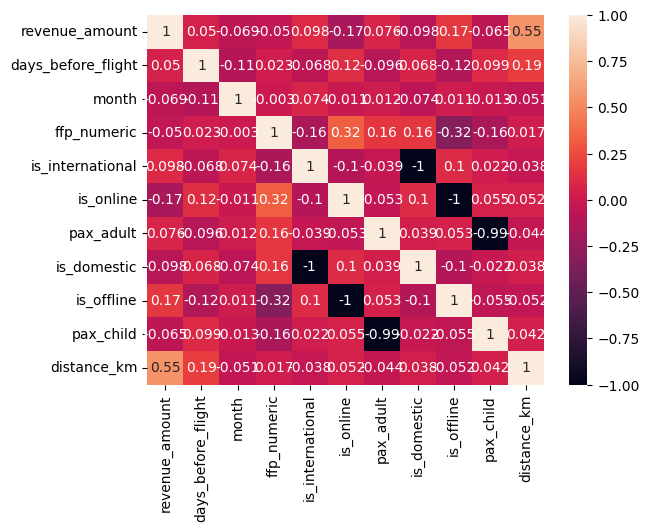

In [153]:
sns.heatmap(matrix, annot=True)

In [155]:
revenue_correlations = matrix['revenue_amount'].sort_values(ascending=False)
for feature, corr in revenue_correlations.items():
    if feature != 'revenue_amount':
        # Определяем силу корреляции
        if abs(corr) > 0.7:
            strength = "Сильная"
        elif abs(corr) > 0.3:
            strength = "Умеренная"
        else:
            strength = "Слабая"
        # Определяем направление
        direction = "положительная" if corr > 0 else "отрицательная"
        # Выводим в нужном формате
        print(f"{feature:20} : {corr:.3f} - {strength}, {direction}")

distance_km          : 0.549 - Умеренная, положительная
is_offline           : 0.172 - Слабая, положительная
is_international     : 0.098 - Слабая, положительная
pax_adult            : 0.076 - Слабая, положительная
days_before_flight   : 0.050 - Слабая, положительная
ffp_numeric          : -0.050 - Слабая, отрицательная
pax_child            : -0.065 - Слабая, отрицательная
month                : -0.069 - Слабая, отрицательная
is_domestic          : -0.098 - Слабая, отрицательная
is_online            : -0.172 - Слабая, отрицательная


#### Таким образом, была проведена корреляция между числовыми признаками и выручкой. Наибольшее влияние оказывает расстояние полета и способ покупки билета.

#### Общий вывод: Было проведено исследование проданных билетов авиакомпании за октябрь 2021 г. - сентябрь 2022 г. В первую очередь, была осуществлена предобработка данных: устранены пропущенные значения и дубликаты, исключены значения выручки, равные нулю. Далее в ходе проведенного исследования были получены следующие основные выводы: <br> 1. Наибольшая выручка от продаж была получена в апреле и в июле 2022 года, а наибольшее число билетов продано в ноябре и в июле. Это говорит об усилении спроса на авиабилеты в период новогодних праздников и летних отпусков. <br> 2. Такой фактор , как наличие программы лояльности не повлиял на увеличение выручки, большинство покупателей не используют данную систему. <br> 3. Большинство клиентов являются взрослыми, поскольку если клиент и покупает детский билет, то он купит и взрослый. <br> 4. Выручку в большей степени создают билеты на внутренние рейсы , чем на международные. <br> 5. В значительной степени выручка от продаж зависит от типа покупки билета ( онлайн или оффлайн), поскольку средняя цена на оффлайн билет выше на 71 ден.ед. <br> 6. Были исключены 464 выброса с минимизацией потерь данных с помощью правила трех сигм, было установлено, что распределение не является нормальным даже после очистки от выбросов.<br> 7. Была принята гипотеза о том , что выручка зимой и осенью не отличается статистически значимо.<br> 8. Было выяснено, что выручка на 87% объясняется количеством продаж. <br> 9.  Клиенты были разделены на три группы по сроку покупки. Отвергаем нулевую гипотезу о том, что выручка от продажи билетов, купленных в последний момент и билетов купленных заранее, не отличается . Она отличается статистически значимо, чаще всего самые дешевые билеты остаются в последний момент (до 3 дней до вылета ). <br> 10. Были определены самые популярные направления перелета , используя дополнительные данные: Сочи-Москва и Москва-Ош. <br> 11. Была исследована корреляция числовых признаков и выручки от продаж. Было выявлено , что выручка на 55% зависит от расстояния полета и на 17.2% от способа покупки билета.